In [619]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler




In [494]:
df = pd.read_csv('project_data.csv', index_col= 0)

In [495]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,NaN,1.0,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2.0,NaN,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1.0,NaN,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2.0,2.0,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3.0,1.0,4,Returning_Visitor,True,False


In [496]:
df. tail(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12320,0,0.00,0,0.0,8,143.583333,0.014286,0.050000,0.000000,0.0,Nov,2,2.0,3.0,1,Returning_Visitor,False,False
12321,0,0.00,0,0.0,6,0.000000,0.200000,0.200000,0.000000,0.0,Nov,1,8.0,4.0,1,Returning_Visitor,False,False
12322,6,76.25,0,0.0,22,1075.250000,0.000000,0.004167,0.000000,0.0,Dec,2,2.0,4.0,2,Returning_Visitor,False,False
12323,2,64.75,0,0.0,44,1157.976190,0.000000,0.013953,0.000000,0.0,Nov,2,2.0,1.0,10,Returning_Visitor,False,False
12324,0,0.00,1,0.0,16,503.000000,0.000000,0.037647,0.000000,0.0,Nov,2,2.0,1.0,1,Returning_Visitor,False,False
12325,3,145.00,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6.0,NaN,1,Returning_Visitor,True,False
12326,0,0.00,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2.0,1.0,8,Returning_Visitor,True,False
12327,0,0.00,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2.0,1.0,13,Returning_Visitor,True,False
12328,4,75.00,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2.0,3.0,11,Returning_Visitor,False,False
12329,0,0.00,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2.0,1.0,2,New_Visitor,True,False


In [497]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12207 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12146 non-null  float64
 13  Region                   12084 non-null  float64
 14  TrafficType              12330 no

In [498]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12207.00000,12330.000000,12146.000000,12084.000000,12330.000000
mean,2.238200,1269.776004,0.503569,34.472398,31.731468,1194.746220,0.044239,0.043073,5.889258,0.06126,2.124006,2.360283,3.145647,4.069586
std,3.409269,34071.466930,1.270156,140.749294,44.475503,1913.669288,0.239735,0.048597,18.568437,0.19865,0.911325,1.722001,2.402440,4.025169
min,-10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.498680,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.00000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,598.936905,0.002896,0.025156,0.000000,0.00000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.787500,0.000000,0.000000,38.000000,1464.157214,0.018029,0.050000,0.000000,0.00000,3.000000,2.000000,4.000000,4.000000
max,27.000000,989493.000000,24.000000,2549.375000,705.000000,63973.522230,2.098952,0.200000,361.763742,1.00000,8.000000,13.000000,9.000000,20.000000


In [499]:
df[["Weekend", "Revenue"]].dtypes

Weekend       str
Revenue    object
dtype: object

In [500]:
df['Revenue'].unique()

array([False, nan, True], dtype=object)

In [501]:
df['Revenue'].value_counts(dropna=False)

Revenue
False    10303
True      1880
NaN        147
Name: count, dtype: int64

In [502]:
missing = df.isna().mean().sort_values(ascending=False)
missing


Region                     0.019951
Browser                    0.014923
Revenue                    0.011922
SpecialDay                 0.009976
ProductRelated             0.000000
ProductRelated_Duration    0.000000
BounceRates                0.000000
ExitRates                  0.000000
PageValues                 0.000000
Administrative_Duration    0.000000
Month                      0.000000
OperatingSystems           0.000000
Informational_Duration     0.000000
Informational              0.000000
TrafficType                0.000000
VisitorType                0.000000
Weekend                    0.000000
Administrative             0.000000
dtype: float64

# Handling of drop-rows

### I record the shape of the DataFrame before starting to drop rows,

### I will use it later after all drops

to compare and check the percentage of data lost from the dataset

this will help in deciding whether to proceed with dropping

or handle it differently if the data loss is too large.

In [503]:

before_dropp_noise = df.shape[0]

In [504]:
before_dropp_noise

12330

# NaNs

### I observe that we have NaNs in our target column, and we cannot train any model if we do not have labels

False = 10303
              
True = 1880

NaN = 147 

compared to the others, they are not many, so I decided to drop them as I do not want to impute anything

In [505]:

df = df.dropna(subset=["Revenue"])


df['Revenue'].value_counts(dropna=False)


Revenue
False    10303
True      1880
Name: count, dtype: int64

In [506]:
df['Weekend'].unique()

<StringArray>
['False', 'True', 'Name:Zara']
Length: 3, dtype: str

In [507]:
df['Weekend'].value_counts()

Weekend
False        9166
True         2833
Name:Zara     184
Name: count, dtype: int64

# NaNs 

### I observe the same issue here with this column, and since I do not want to impute, I choose to drop them as they are not many.

In [508]:

df = df[df['Weekend'].isin(['True', 'False'])].copy()

In [509]:
df['Weekend'].value_counts(dropna=False)

Weekend
False    9166
True     2833
Name: count, dtype: int64

# Okay, good, now we continue

### most of the columns are numeric, which is good,

### our target is the column 'Revenue' with data-type: object, values [True/False], representing whether the customer completed a purchase = 'True', or not = 'False'

### column 'Weekend' with data-type: str, values [True/False]

### we will convert these two columns to binary so it becomes appropriate to use them later.

In [510]:

T_F_columns = ["Weekend", "Revenue"]

df[T_F_columns] = (df[T_F_columns]
                   .astype(str)
                   .apply(lambda s: s.str.strip().str.lower())
                   .replace({"true": 1, "false": 0})
                  ).astype("int64")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,NaN,1.0,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2.0,NaN,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1.0,NaN,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2.0,2.0,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3.0,1.0,4,Returning_Visitor,1,0


In [511]:
missing = df.isna().mean().sort_values(ascending=False)
missing


Region                     0.020168
Browser                    0.015001
SpecialDay                 0.010084
Administrative_Duration    0.000000
Weekend                    0.000000
VisitorType                0.000000
TrafficType                0.000000
OperatingSystems           0.000000
Month                      0.000000
Administrative             0.000000
PageValues                 0.000000
ExitRates                  0.000000
BounceRates                0.000000
ProductRelated_Duration    0.000000
ProductRelated             0.000000
Informational_Duration     0.000000
Informational              0.000000
Revenue                    0.000000
dtype: float64

# Okay, we have columns with NaNs in percentage terms: Region = 2.02%, Browser = 1.5%, SpecialDay = 1.01%

### I also do not want to impute anything here; we might lose some data if we drop NaNs (up to 2% of the dataset), but I prefer not to impute,

### especially since we currently do not have access to domain experts to discuss what we could impute if we decided to do so

### for me, the safest option right now is to drop them so I can move forward.

In [512]:


df = df.dropna(subset=["Region", "Browser", "SpecialDay"])



missing = df.isna().mean().sort_values(ascending=False)
missing



Administrative             0.0
Administrative_Duration    0.0
Weekend                    0.0
VisitorType                0.0
TrafficType                0.0
Region                     0.0
Browser                    0.0
OperatingSystems           0.0
Month                      0.0
SpecialDay                 0.0
PageValues                 0.0
ExitRates                  0.0
BounceRates                0.0
ProductRelated_Duration    0.0
ProductRelated             0.0
Informational_Duration     0.0
Informational              0.0
Revenue                    0.0
dtype: float64

In [513]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2.0,2.0,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3.0,1.0,4,Returning_Visitor,1,0
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2.0,1.0,3,Returning_Visitor,0,0
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4.0,3.0,3,Returning_Visitor,0,0
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2.0,1.0,5,Returning_Visitor,1,0


In [514]:
df['Month'].value_counts()

Month
May     2943
Nov     2794
Mar     1781
Dec     1600
Oct      520
Aug      408
Jul      400
Sep      338
June     268
Feb      168
Turc     160
Sept      84
Name: count, dtype: int64

# Month Column

In the Month column, we have the value 'Turc', which is not a valid month name.

If we investigate further, we see that both January and April are missing from the list, which suggests that it could be one of those months.

However, we cannot clearly identify what 'Turc' represents, which means we have no choice but to assume that 'Turc' is either a typo or an incorrect value.

In both cases, it must be handled:

the value 'Turc' appears in 160 rows in the dataset, so the safest approach is to drop the rows with the value 'Turc' in the Month column.

In [515]:



df = df[df["Month"].astype(str).str.strip() != "Turc"].copy()

In [516]:
after_dropp_noise = df.shape[0]
after_dropp_noise

11304

In [517]:
before_dropp_noise

12330

# After all 

### we check how much of the data we have dropped/lost in percentage terms

In [518]:
print("dropped:", before_dropp_noise - after_dropp_noise)
print("dropped_%:", (before_dropp_noise - after_dropp_noise) / before_dropp_noise * 100)

dropped: 1026
dropped_%: 8.321167883211679


In [519]:
df.info()

<class 'pandas.DataFrame'>
Index: 11304 entries, 3 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           11304 non-null  int64  
 1   Administrative_Duration  11304 non-null  float64
 2   Informational            11304 non-null  int64  
 3   Informational_Duration   11304 non-null  float64
 4   ProductRelated           11304 non-null  int64  
 5   ProductRelated_Duration  11304 non-null  float64
 6   BounceRates              11304 non-null  float64
 7   ExitRates                11304 non-null  float64
 8   PageValues               11304 non-null  float64
 9   SpecialDay               11304 non-null  float64
 10  Month                    11304 non-null  str    
 11  OperatingSystems         11304 non-null  int64  
 12  Browser                  11304 non-null  float64
 13  Region                   11304 non-null  float64
 14  TrafficType              11304 non-nul

# Month column

### we are still working on this column,

### we have 2 values for the month of September that need to be fixed: one is "Sep", which matches the format of other month names using the first three letters. The other is "Sept", and we need to change it so everything is clean and we avoid confusion later when doing mapping.

In [520]:
df['Month'].value_counts()

Month
May     2943
Nov     2794
Mar     1781
Dec     1600
Oct      520
Aug      408
Jul      400
Sep      338
June     268
Feb      168
Sept      84
Name: count, dtype: int64

In [521]:
df["Month"].isna().sum()

np.int64(0)

In [522]:
df['Month'] = df['Month'].replace('Sept', 'Sep')

In [523]:
df['Month'].value_counts()

Month
May     2943
Nov     2794
Mar     1781
Dec     1600
Oct      520
Sep      422
Aug      408
Jul      400
June     268
Feb      168
Name: count, dtype: int64

# nice nu kan vi göra maping över Month kolumnen .... men vänta lite :

### I was planning to use regular mapping or one-hot encoding for the Month column, but after looking into it, I found that simple mapping is not the best approach and does not represent reality properly since the year is cyclical.

### In this case, order actually matters because people tend to buy more during periods like Christmas and Black Friday compared to other times of the year. So I will use cyclic encoding instead.

### With regular linear mapping, for example, December would be very far away from January, which does not reflect reality.

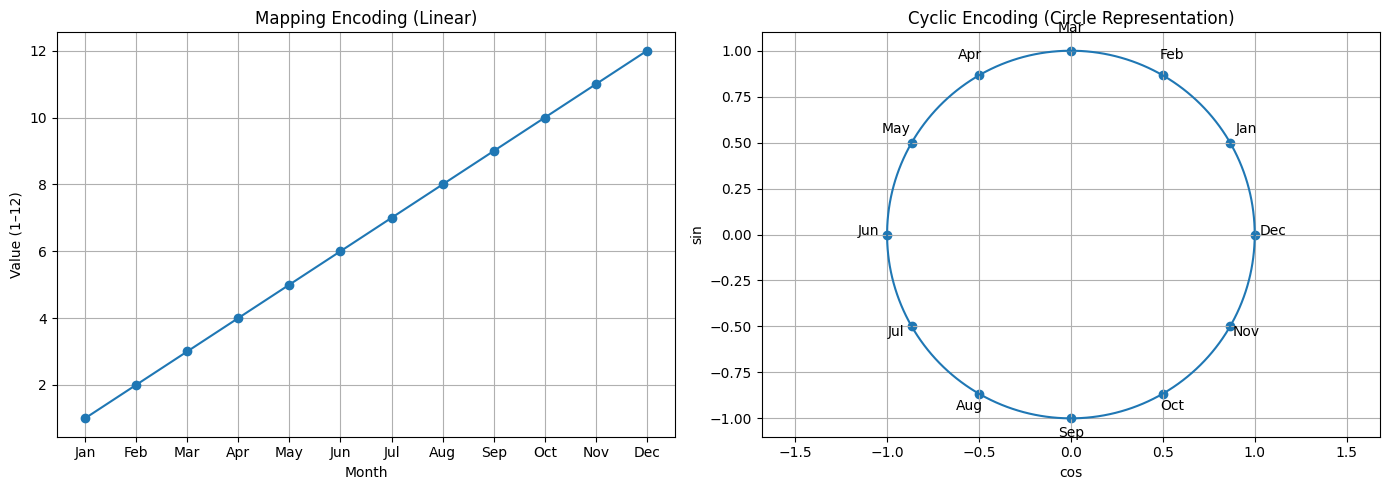

In [ ]:

months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]


month_map = {m: i+1 for i, m in enumerate(months)}

mapped_values = [month_map[m] for m in months]


mapped_numeric = np.array(mapped_values)

month_sin = np.sin(2 * np.pi * mapped_numeric / 12)
month_cos = np.cos(2 * np.pi * mapped_numeric / 12)


plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(months, mapped_values, marker='o')
plt.title("Mapping Encoding (Linear)")
plt.xlabel("Month")
plt.ylabel("Value (1–12)")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(month_cos, month_sin)

for i, m in enumerate(months):
    plt.text(month_cos[i]*1.1, month_sin[i]*1.1, m, ha='center')

circle = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(circle), np.sin(circle))

plt.title("Cyclic Encoding (Circle Representation)")
plt.xlabel("cos")
plt.ylabel("sin")
plt.axis("equal")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

df["Month"] = df["Month"].str.strip().str[:3]

df["Month_num"] = df["Month"].map(month_map)

df["Month_sin"] = np.sin(2 * np.pi * df["Month_num"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month_num"] / 12)

In [526]:
df = df.drop("Month", axis=1)

In [527]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Month_num,Month_sin,Month_cos
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,3,2.0,2.0,4,Returning_Visitor,0,0,2,0.866025,0.5
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,3,3.0,1.0,4,Returning_Visitor,1,0,2,0.866025,0.5
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,2,2.0,1.0,3,Returning_Visitor,0,0,2,0.866025,0.5
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,2,4.0,3.0,3,Returning_Visitor,0,0,2,0.866025,0.5
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,1,2.0,1.0,5,Returning_Visitor,1,0,2,0.866025,0.5


In [528]:
df.tail(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Month_num,Month_sin,Month_cos
12319,0,0.00,0,0.0,21,1128.583333,0.000000,0.013043,3.685401,0.0,2,2.0,1.0,2,Returning_Visitor,0,0,12,-2.449294e-16,1.000000
12320,0,0.00,0,0.0,8,143.583333,0.014286,0.050000,0.000000,0.0,2,2.0,3.0,1,Returning_Visitor,0,0,11,-5.000000e-01,0.866025
12321,0,0.00,0,0.0,6,0.000000,0.200000,0.200000,0.000000,0.0,1,8.0,4.0,1,Returning_Visitor,0,0,11,-5.000000e-01,0.866025
12322,6,76.25,0,0.0,22,1075.250000,0.000000,0.004167,0.000000,0.0,2,2.0,4.0,2,Returning_Visitor,0,0,12,-2.449294e-16,1.000000
12323,2,64.75,0,0.0,44,1157.976190,0.000000,0.013953,0.000000,0.0,2,2.0,1.0,10,Returning_Visitor,0,0,11,-5.000000e-01,0.866025
12324,0,0.00,1,0.0,16,503.000000,0.000000,0.037647,0.000000,0.0,2,2.0,1.0,1,Returning_Visitor,0,0,11,-5.000000e-01,0.866025
12326,0,0.00,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,3,2.0,1.0,8,Returning_Visitor,1,0,11,-5.000000e-01,0.866025
12327,0,0.00,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,3,2.0,1.0,13,Returning_Visitor,1,0,11,-5.000000e-01,0.866025
12328,4,75.00,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,2,2.0,3.0,11,Returning_Visitor,0,0,11,-5.000000e-01,0.866025
12329,0,0.00,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,3,2.0,1.0,2,New_Visitor,1,0,11,-5.000000e-01,0.866025


# VisitorType kolumnen 

In [529]:
df['VisitorType'].value_counts(dropna=False)

VisitorType
Returning_Visitor    9659
New_Visitor          1567
Other                  78
Name: count, dtype: int64

### okay then we will apply one-hot encoding on this column so it gets split into three different values

In [530]:
df = pd.get_dummies(df, columns= ['VisitorType'], drop_first=True)

In [531]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend',
       'Revenue', 'Month_num', 'Month_sin', 'Month_cos', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='str')

In [532]:
missing_after = df.isna().mean().sort_values(ascending=False)
missing_after

Administrative                   0.0
Browser                          0.0
VisitorType_Other                0.0
Month_cos                        0.0
Month_sin                        0.0
Month_num                        0.0
Revenue                          0.0
Weekend                          0.0
TrafficType                      0.0
Region                           0.0
OperatingSystems                 0.0
Administrative_Duration          0.0
SpecialDay                       0.0
PageValues                       0.0
ExitRates                        0.0
BounceRates                      0.0
ProductRelated_Duration          0.0
ProductRelated                   0.0
Informational_Duration           0.0
Informational                    0.0
VisitorType_Returning_Visitor    0.0
dtype: float64

### okay let's check how many duplicates we have

In [533]:
df.duplicated().sum()


np.int64(92)

### Okej då droppa vi det 

In [534]:
df = df.drop_duplicates()

In [535]:
df.duplicated().sum()


np.int64(0)

# 'BounceRates', 'ExitRates'

### now we will start looking at what interesting values we have here

In [536]:
df[df["BounceRates"] < 0]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,Weekend,Revenue,Month_num,Month_sin,Month_cos,VisitorType_Other,VisitorType_Returning_Visitor
15,2,53.00,0,0.0,23,1668.285119,-0.395564,0.016313,0.000000,0.0,...,1.0,9.0,3,0,0,2,8.660254e-01,0.500000,False,True
42,0,0.00,0,0.0,15,310.166667,-0.409885,0.006667,0.000000,0.0,...,1.0,4.0,4,0,0,2,8.660254e-01,0.500000,False,True
45,0,0.00,0,0.0,22,622.250000,-0.458046,0.006061,0.000000,0.2,...,5.0,1.0,4,0,0,2,8.660254e-01,0.500000,False,True
67,0,0.00,0,0.0,1,0.000000,-0.141745,0.200000,0.000000,0.6,...,2.0,5.0,1,0,0,2,8.660254e-01,0.500000,False,True
170,1,0.00,0,0.0,15,487.500000,-0.432621,0.019167,0.000000,0.8,...,1.0,2.0,4,1,0,2,8.660254e-01,0.500000,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12032,1,58.50,0,0.0,23,1033.000000,-0.166448,0.037500,0.000000,0.0,...,2.0,3.0,2,0,0,12,-2.449294e-16,1.000000,False,True
12212,0,0.00,0,0.0,13,223.416667,-0.449637,0.023077,0.000000,0.0,...,4.0,1.0,2,0,0,12,-2.449294e-16,1.000000,False,True
12263,2,23.00,0,0.0,12,284.500000,-0.397288,0.014286,0.000000,0.0,...,2.0,3.0,2,0,0,12,-2.449294e-16,1.000000,False,True
12266,2,223.75,3,165.0,51,2159.004167,-0.259273,0.037347,10.229937,0.0,...,1.0,1.0,2,0,0,11,-5.000000e-01,0.866025,False,True


In [537]:
df[df["ExitRates"] < 0]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,Weekend,Revenue,Month_num,Month_sin,Month_cos,VisitorType_Other,VisitorType_Returning_Visitor


## okay the values for ExitRates seem reasonable as we can see here

In [538]:
df['ExitRates'].min()

np.float64(0.0)

In [539]:
df['ExitRates'].max()

np.float64(0.2)

## but here in BounceRates the values look strange

In [540]:
df["BounceRates"].min()

np.float64(-0.4986798792563108)

In [541]:
df['BounceRates'].max()

np.float64(2.088658098341644)

In [542]:
df['BounceRates'].describe()

count    11212.000000
mean         0.042137
std          0.238515
min         -0.498680
25%          0.000000
50%          0.002667
75%          0.017021
max          2.088658
Name: BounceRates, dtype: float64

In [543]:
(df['BounceRates'] < 0) .sum()

np.int64(338)

In [544]:
(df['BounceRates'] > 0) .sum()

np.int64(6065)

In [545]:
(df["BounceRates"] > 1).sum()

np.int64(221)

In [546]:
(df["BounceRates"] == 0).sum()

np.int64(4809)

In [547]:
print("Less than 0:", (df["BounceRates"] < 0).sum())
print("Greater than 1:", (df["BounceRates"] > 1).sum())
print("Equal to 0:", (df["BounceRates"] == 0).sum())
print("Between 0 and 1:", ((df["BounceRates"] >= 0) & (df["BounceRates"] <= 1)).sum())


Less than 0: 338
Greater than 1: 221
Equal to 0: 4809
Between 0 and 1: 10653


### As we can see above, we have discovered that 'ExitRates' looks normal and all values are between 0 - 1

### But the problem here is that 'BounceRates' has some invalid values. This variable represents a proportion, meaning values should be between 0 - 1 to be valid

### therefore, I consider the values outside this range as incorrect, and they will be removed before I continue.

In [548]:
df = df[(df["BounceRates"] >= 0) & (df["BounceRates"] <= 1)]


print("Less than 0:", (df["BounceRates"] < 0).sum())
print("Greater than 1:", (df["BounceRates"] > 1).sum())
print("Equal to 0:", (df["BounceRates"] == 0).sum())
print("Between 0 and 1:", ((df["BounceRates"] >= 0) & (df["BounceRates"] <= 1)).sum())


Less than 0: 0
Greater than 1: 0
Equal to 0: 4809
Between 0 and 1: 10653


In [549]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_num,Month_sin,Month_cos
count,10653.00000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,10653.000000,1.065300e+04,1.065300e+04
mean,2.24885,1365.999851,0.505116,34.911168,32.130667,1206.890276,0.020381,0.041360,5.757656,0.059420,2.127570,2.358772,3.139961,4.103914,0.236084,0.155543,7.711912,4.615633e-02,8.658336e-02
std,3.40279,35429.308425,1.274146,143.003889,45.049270,1942.072566,0.045221,0.046132,17.532322,0.195986,0.905383,1.709485,2.395082,4.052115,0.424694,0.362439,3.390789,6.322332e-01,7.686007e-01
min,-10.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,2.000000,-1.000000e+00,-1.000000e+00
25%,0.00000,0.000000,0.000000,0.000000,8.000000,193.366667,0.000000,0.014048,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000,5.000000,-5.000000e-01,-8.660254e-01
50%,1.00000,9.100000,0.000000,0.000000,18.000000,607.000000,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000,8.000000,-2.449294e-16,6.123234e-17
75%,4.00000,94.000000,0.000000,0.000000,38.000000,1475.266667,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000,11.000000,5.000000e-01,8.660254e-01
max,27.00000,989493.000000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,287.953793,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000,12.000000,1.000000e+00,1.000000e+00


In [550]:
cols_non_negative = [
    "Administrative", "Informational", "ProductRelated",
    "Administrative_Duration", "Informational_Duration", "ProductRelated_Duration",
    "PageValues"
]

for col in cols_non_negative:
    print(col, "min =", df[col].min())

print("SpecialDay min =", df["SpecialDay"].min())
print("SpecialDay max =", df["SpecialDay"].max())


Administrative min = -10
Informational min = 0
ProductRelated min = 0
Administrative_Duration min = 0.0
Informational_Duration min = 0.0
ProductRelated_Duration min = 0.0
PageValues min = 0.0
SpecialDay min = 0.0
SpecialDay max = 1.0


# Aha

### * check this, 'Administrative' is a variable that represents number of page visits, but we can see here that we have negative values

### * values for this variable must be >= 0 to be valid, because you cannot for example visit -3 pages !!! it makes no sense !!

### * let's check how many there are:

In [551]:
(df["Administrative"] < 0).sum()


np.int64(108)

## okay here we see that we have 108 invalid values and I decide to remove them so I can move forward

In [552]:
df = df[df["Administrative"] >= 0]

In [553]:
(df["Administrative"] < 0).sum()


np.int64(0)

In [554]:
cols_non_negative = [
    "Administrative", "Informational", "ProductRelated",
    "Administrative_Duration", "Informational_Duration", "ProductRelated_Duration",
    "PageValues"
]

for col in cols_non_negative:
    print(col, "min =", df[col].min())

print("SpecialDay min =", df["SpecialDay"].min())
print("SpecialDay max =", df["SpecialDay"].max())


Administrative min = 0
Informational min = 0
ProductRelated min = 0
Administrative_Duration min = 0.0
Informational_Duration min = 0.0
ProductRelated_Duration min = 0.0
PageValues min = 0.0
SpecialDay min = 0.0
SpecialDay max = 1.0


# Alright, now we are basically at the final check!

In [555]:
cols_to_check = ["Revenue", "OperatingSystems", "Browser", "Region", "TrafficType", "Weekend"]

for col in cols_to_check:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: Revenue
Revenue
0    8902
1    1643
Name: count, dtype: int64

Column: OperatingSystems
OperatingSystems
2    5650
3    2209
1    2176
4     419
8      65
6      15
5       6
7       5
Name: count, dtype: int64

Column: Browser
Browser
2.0     6838
1.0     2076
4.0      614
5.0      407
6.0      151
10.0     138
8.0      117
3.0       94
13.0      49
7.0       45
12.0       9
11.0       6
9.0        1
Name: count, dtype: int64

Column: Region
Region
1.0    4083
3.0    2058
4.0    1008
2.0     980
6.0     692
7.0     642
9.0     429
8.0     372
5.0     281
Name: count, dtype: int64

Column: TrafficType
TrafficType
2     3364
1     2079
3     1738
4      887
13     635
10     395
6      384
8      302
11     222
5      220
20     172
7       38
9       36
15      33
19      13
14      12
18      10
16       3
12       1
17       1
Name: count, dtype: int64

Column: Weekend
Weekend
0    8047
1    2498
Name: count, dtype: int64


In [556]:
cols_to_check = ["Revenue", "OperatingSystems", "Browser", "Region", "TrafficType", "Weekend"]

for col in cols_to_check:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False))


Column: Revenue
Unique values: 2
Revenue
0    8902
1    1643
Name: count, dtype: int64

Column: OperatingSystems
Unique values: 8
OperatingSystems
2    5650
3    2209
1    2176
4     419
8      65
6      15
5       6
7       5
Name: count, dtype: int64

Column: Browser
Unique values: 13
Browser
2.0     6838
1.0     2076
4.0      614
5.0      407
6.0      151
10.0     138
8.0      117
3.0       94
13.0      49
7.0       45
12.0       9
11.0       6
9.0        1
Name: count, dtype: int64

Column: Region
Unique values: 9
Region
1.0    4083
3.0    2058
4.0    1008
2.0     980
6.0     692
7.0     642
9.0     429
8.0     372
5.0     281
Name: count, dtype: int64

Column: TrafficType
Unique values: 20
TrafficType
2     3364
1     2079
3     1738
4      887
13     635
10     395
6      384
8      302
11     222
5      220
20     172
7       38
9       36
15      33
19      13
14      12
18      10
16       3
12       1
17       1
Name: count, dtype: int64

Column: Weekend
Unique values: 2
Wee

# Nice, it looks like we have done what needs to be done with the columns so far

### Revenue is correct as a binary target variable: 0 and 1

### Weekend is also correctly binary: 0 and 1
### OperatingSystems, Browser, Region, TrafficType look like categorical encoded variables with reasonable values

#### -we can just make Browser and Region a bit cleaner

In [557]:
df["Browser"] = df["Browser"].astype(int)
df["Region"] = df["Region"].astype(int)

df['Browser']

3        2
4        3
5        2
6        4
7        2
        ..
12324    2
12326    2
12327    2
12328    2
12329    2
Name: Browser, Length: 10545, dtype: int64

In [558]:
df['Region']

3        2
4        1
5        1
6        3
7        1
        ..
12324    1
12326    1
12327    1
12328    3
12329    1
Name: Region, Length: 10545, dtype: int64

## * Let's check the class distribution in our target

In [559]:
print(df["Revenue"].value_counts())
print(df["Revenue"].value_counts(normalize=True) * 100)


Revenue
0    8902
1    1643
Name: count, dtype: int64
Revenue
0    84.419156
1    15.580844
Name: proportion, dtype: float64


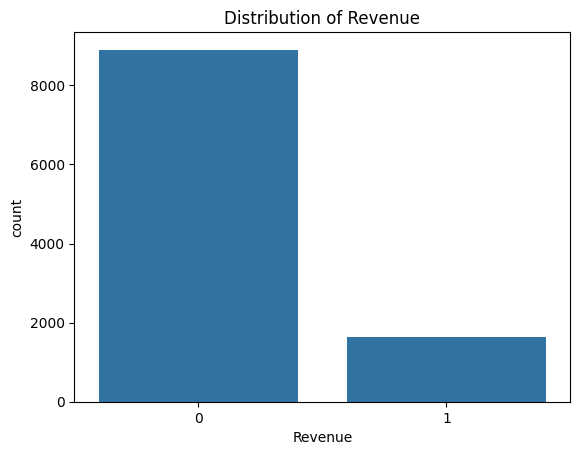

In [560]:
sns.countplot(x="Revenue", data=df)
plt.title("Distribution of Revenue")
plt.show()

# Important NOTE

## as we can see above

### class 0 = 84 % 
### class 1 = 16 %

### this shows that 'Revenue' is IMBALANCED !!

### and this will cause the model to get high accuracy just by often predicting 0, but still the model will be poor at finding the customers who actually make a purchase.

### >>>> we should keep this in mind later when we train the model

In [561]:
print("Shape of dataset:", df.shape)


print("\nData types:")
print(df.dtypes)



Shape of dataset: (10545, 21)

Data types:
Administrative                     int64
Administrative_Duration          float64
Informational                      int64
Informational_Duration           float64
ProductRelated                     int64
ProductRelated_Duration          float64
BounceRates                      float64
ExitRates                        float64
PageValues                       float64
SpecialDay                       float64
OperatingSystems                   int64
Browser                            int64
Region                             int64
TrafficType                        int64
Weekend                            int64
Revenue                            int64
Month_num                          int64
Month_sin                        float64
Month_cos                        float64
VisitorType_Other                   bool
VisitorType_Returning_Visitor       bool
dtype: object


In [562]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,Weekend,Revenue,Month_num,Month_sin,Month_cos,VisitorType_Other,VisitorType_Returning_Visitor
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,...,2,2,4,0,0,2,0.866025,0.5,False,True
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,...,3,1,4,1,0,2,0.866025,0.5,False,True
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,...,2,1,3,0,0,2,0.866025,0.5,False,True
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,...,4,3,3,0,0,2,0.866025,0.5,False,True
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,...,2,1,5,1,0,2,0.866025,0.5,False,True


In [563]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,Weekend,Revenue,Month_num,Month_sin,Month_cos,VisitorType_Other,VisitorType_Returning_Visitor
12324,0,0.0,1,0.0,16,503.00,0.000000,0.037647,0.0,0.0,...,2,1,1,0,0,11,-0.5,0.866025,False,True
12326,0,0.0,0,0.0,5,465.75,0.000000,0.021333,0.0,0.0,...,2,1,8,1,0,11,-0.5,0.866025,False,True
12327,0,0.0,0,0.0,6,184.25,0.083333,0.086667,0.0,0.0,...,2,1,13,1,0,11,-0.5,0.866025,False,True
12328,4,75.0,0,0.0,15,346.00,0.000000,0.021053,0.0,0.0,...,2,3,11,0,0,11,-0.5,0.866025,False,True
12329,0,0.0,0,0.0,3,21.25,0.000000,0.066667,0.0,0.0,...,2,1,2,1,0,11,-0.5,0.866025,False,False


In [564]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_num,Month_sin,Month_cos
count,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,1.054500e+04,1.054500e+04
mean,2.329540,1379.237799,0.504220,34.529291,32.117307,1206.856868,0.020321,0.041313,5.775467,0.058872,2.129350,2.359602,3.142437,4.099858,0.236890,0.155808,7.717402,4.470701e-02,8.682491e-02
std,3.313676,35610.047306,1.272747,140.926209,45.021585,1942.659182,0.045108,0.046048,17.570491,0.195126,0.905407,1.711183,2.394870,4.049882,0.425194,0.362691,3.388841,6.322923e-01,7.686111e-01
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,2.000000,-1.000000e+00,-1.000000e+00
25%,0.000000,0.000000,0.000000,0.000000,8.000000,194.000000,0.000000,0.014035,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000,5.000000,-5.000000e-01,-8.660254e-01
50%,1.000000,9.600000,0.000000,0.000000,18.000000,607.466667,0.002857,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000,8.000000,-2.449294e-16,6.123234e-17
75%,4.000000,94.000000,0.000000,0.000000,38.000000,1475.366667,0.016667,0.048485,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000,11.000000,5.000000e-01,8.660254e-01
max,27.000000,989493.000000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,287.953793,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000,12.000000,1.000000e+00,1.000000e+00


In [565]:
df.isna().sum()

Administrative                   0
Administrative_Duration          0
Informational                    0
Informational_Duration           0
ProductRelated                   0
ProductRelated_Duration          0
BounceRates                      0
ExitRates                        0
PageValues                       0
SpecialDay                       0
OperatingSystems                 0
Browser                          0
Region                           0
TrafficType                      0
Weekend                          0
Revenue                          0
Month_num                        0
Month_sin                        0
Month_cos                        0
VisitorType_Other                0
VisitorType_Returning_Visitor    0
dtype: int64

## Let's check the numerical columns

In [566]:
numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month_num"
]

display(df[numerical_cols].describe())


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month_num
count,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000,10545.000000
mean,2.329540,1379.237799,0.504220,34.529291,32.117307,1206.856868,0.020321,0.041313,5.775467,0.058872,7.717402
std,3.313676,35610.047306,1.272747,140.926209,45.021585,1942.659182,0.045108,0.046048,17.570491,0.195126,3.388841
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,194.000000,0.000000,0.014035,0.000000,0.000000,5.000000
50%,1.000000,9.600000,0.000000,0.000000,18.000000,607.466667,0.002857,0.025000,0.000000,0.000000,8.000000
75%,4.000000,94.000000,0.000000,0.000000,38.000000,1475.366667,0.016667,0.048485,0.000000,0.000000,11.000000
max,27.000000,989493.000000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,287.953793,1.000000,12.000000


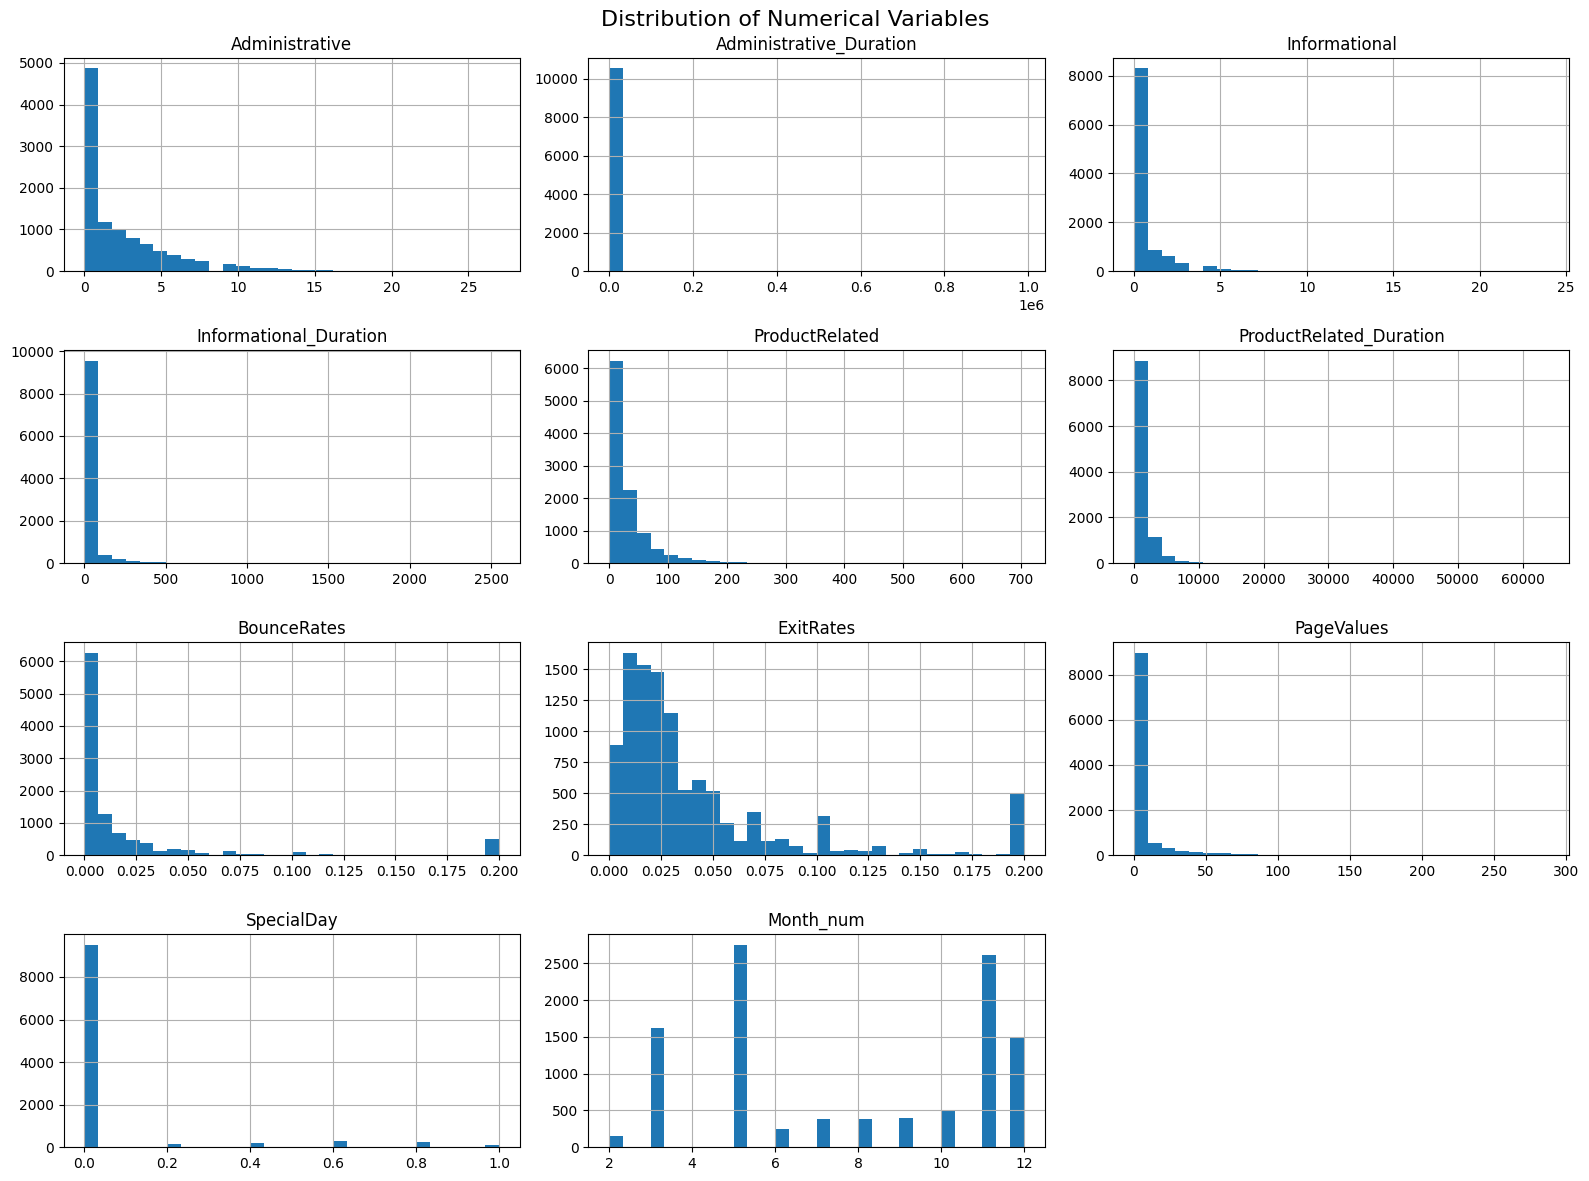

In [567]:
df[numerical_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

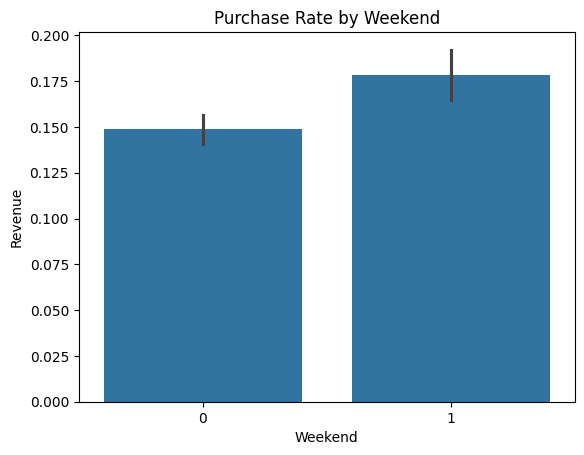

In [568]:
sns.barplot(x="Weekend", y="Revenue", data=df)
plt.title("Purchase Rate by Weekend")
plt.show()

## Let's investigate how important our numerical columns are:

### if the bar for Revenue = 1 is HIGHER than for Revenue = 0: then the purchasing group has on average a higher value for that variable

### if the bar for Revenue = 1 is LOWER than for Revenue = 0: then the purchasing group has on average a lower value for that variable

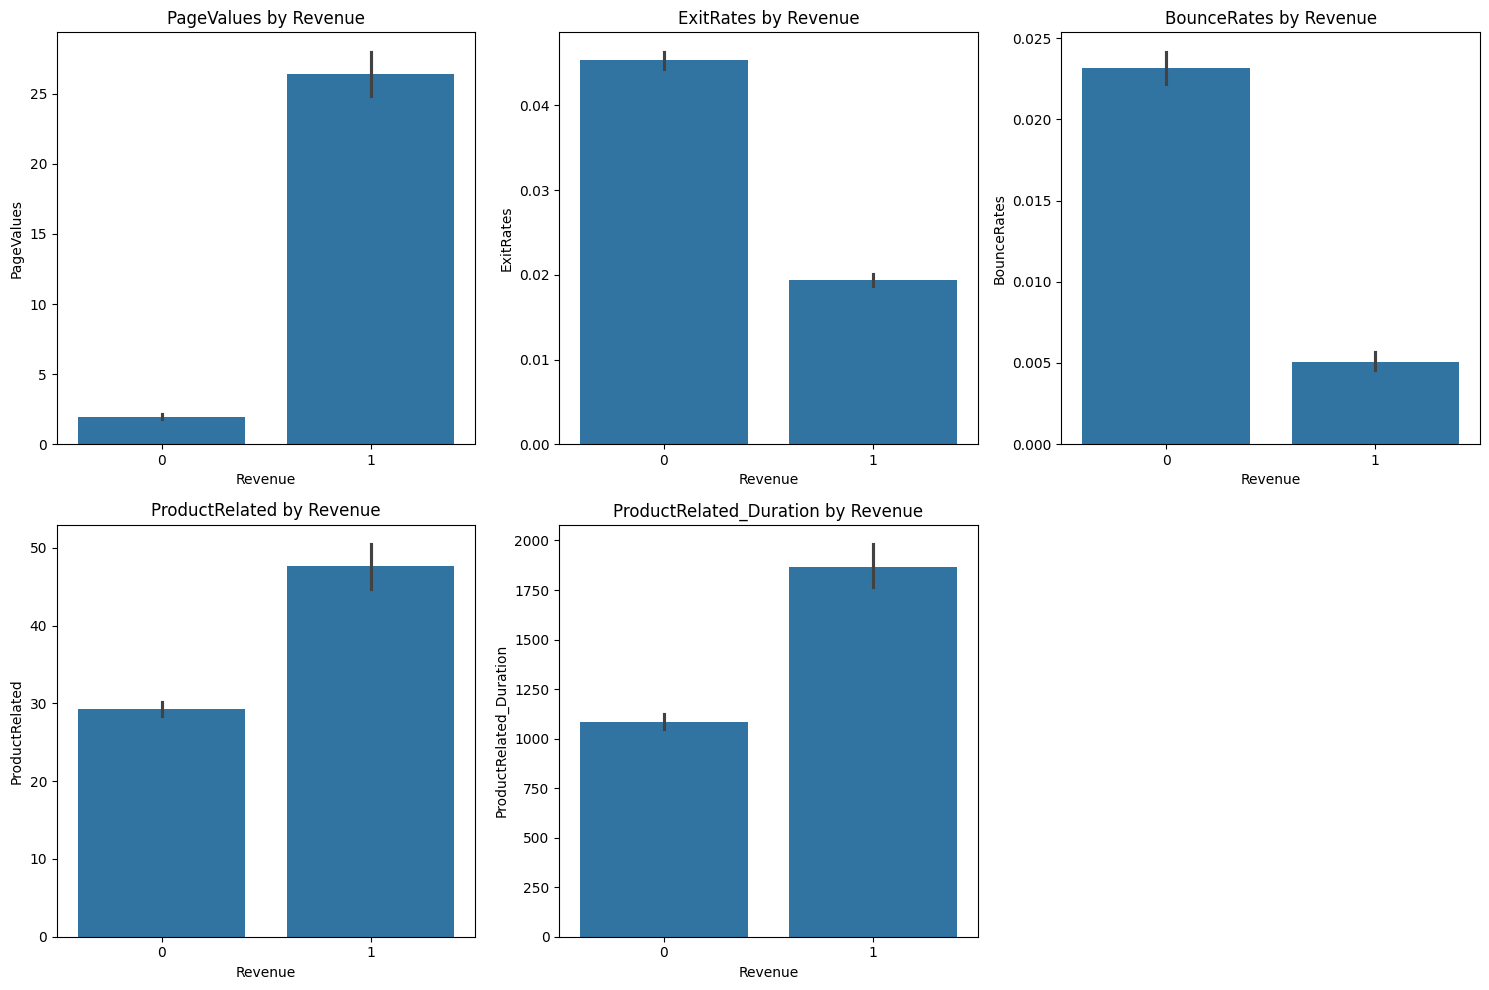

In [569]:
important_num_cols = [
    "PageValues",
    "ExitRates",
    "BounceRates",
    "ProductRelated",
    "ProductRelated_Duration"
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(important_num_cols, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x="Revenue", y=col, data=df)
    plt.title(f"{col} by Revenue")

plt.tight_layout()
plt.show()


In [570]:
df.groupby("Revenue")[important_num_cols].mean()


,PageValues,ExitRates,BounceRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
0,1.963945,0.045357,0.023133,29.250618,1084.788532
1,26.426816,0.019399,0.005082,47.649422,1868.239902


# Now we will look at our categorical columns against Revenue

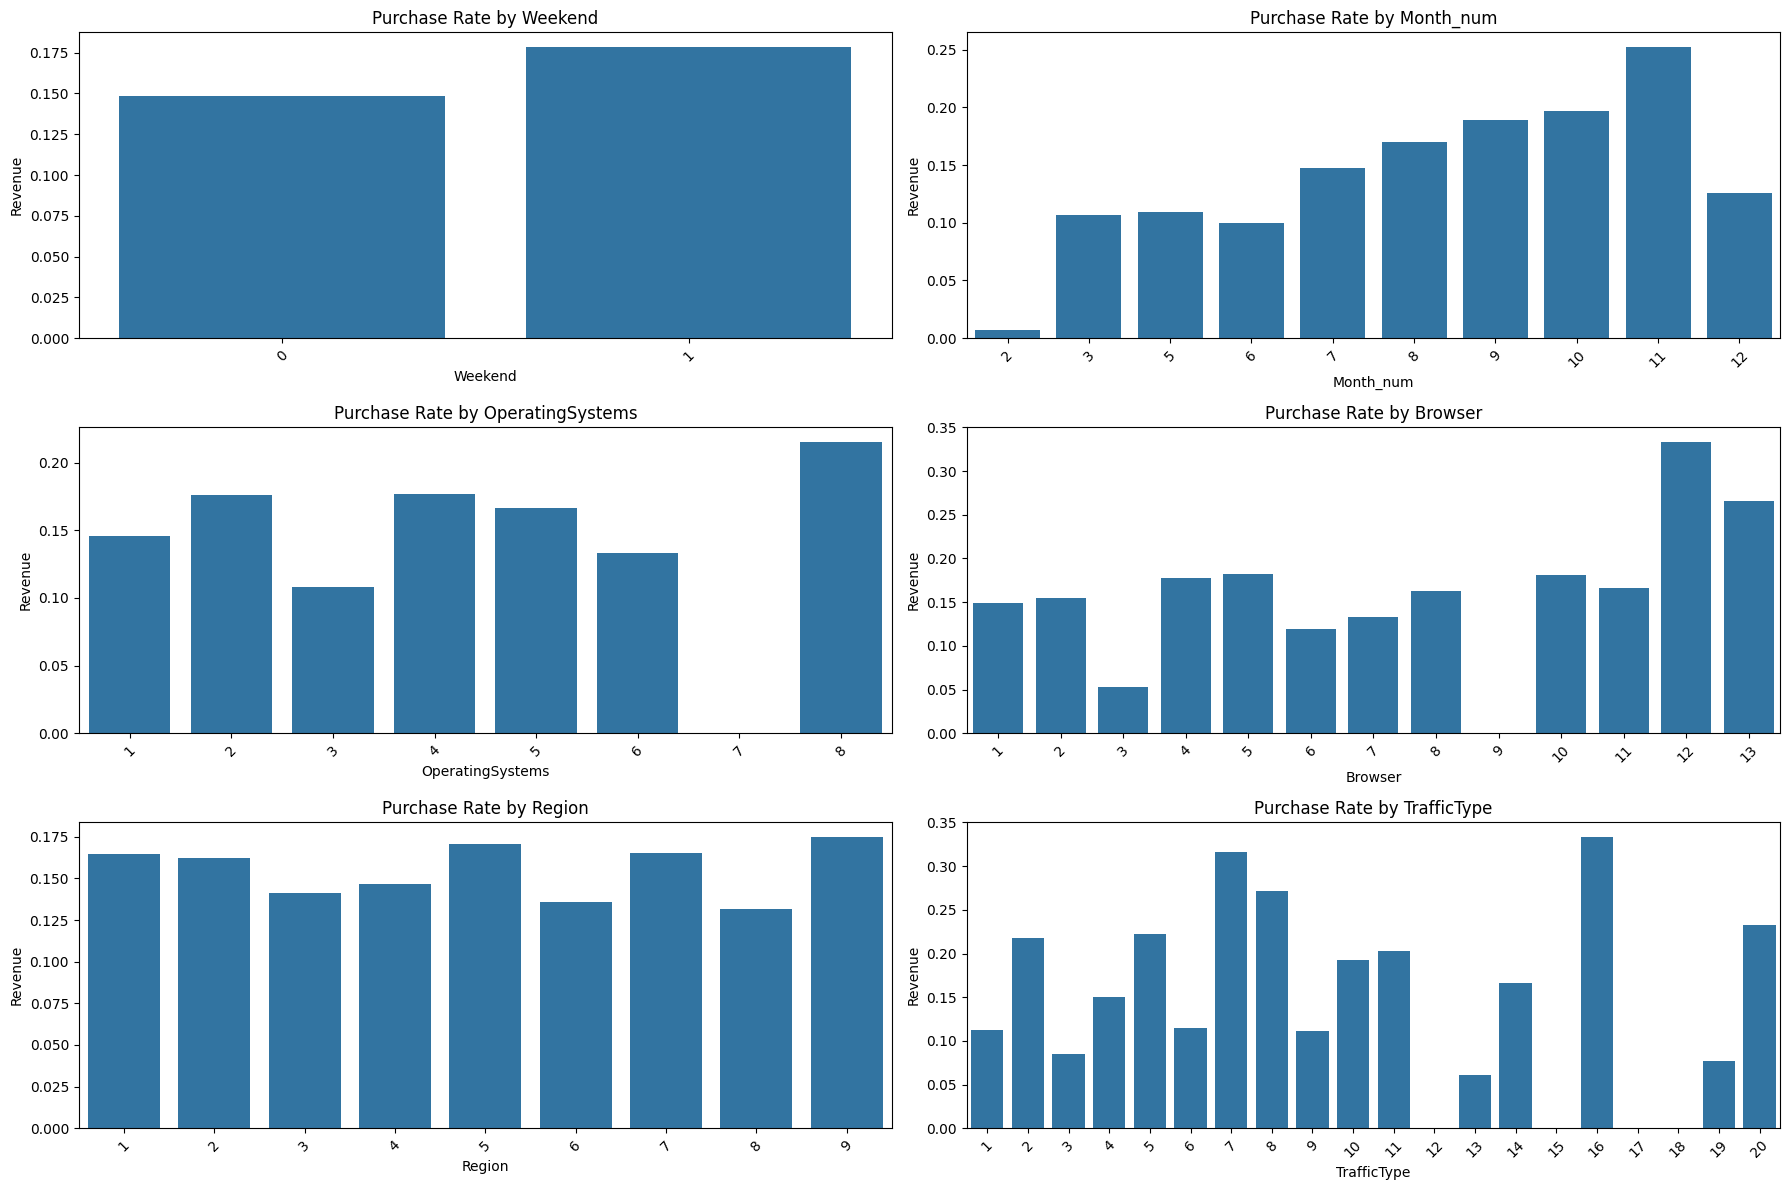

In [571]:

categorical_cols = ["Weekend", "Month_num", "OperatingSystems", "Browser", "Region", "TrafficType"]

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.barplot(x=col, y="Revenue", data=df, estimator="mean", errorbar=None)
    plt.title(f"Purchase Rate by {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# EDA Summary

## if we look at the plot for NUMERICAL columns, we notice that:

##### * "PageValues", "ExitRates", "BounceRates" seem to be important and separate purchases from non-purchases.


## if we look at the plot for CATEGORICAL columns, we notice that:

##### * 'month_num', 'OperatingSystem', 'Browser', 'TrafficType' seem to be especially important and have a stronger impact

---

# FINALLY

## Now we are going to start with the fun part,

### Train/Validate/Test split

In [572]:

X = df.drop("Revenue", axis=1)
y = df["Revenue"]

# Här delar vi på 70% train , 30% hold för vi ska dela den 30% till 15% validate / 15% test
X_train, X_hold, y_train, y_hold = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# Här delar vi dem 30% på validate/test 
X_val, X_test, y_val, y_test = train_test_split(
    X_hold, y_hold,
    test_size=0.50,
    random_state=42,
    stratify=y_hold
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("Train distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

print("\nValidation distribution:")
print((y_val.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

print("\nTest distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + "%")


X_train shape: (7381, 20)
X_val shape: (1582, 20)
X_test shape: (1582, 20)
Train distribution:
Revenue
0    84.42%
1    15.58%
Name: proportion, dtype: str

Validation distribution:
Revenue
0    84.39%
1    15.61%
Name: proportion, dtype: str

Test distribution:
Revenue
0    84.45%
1    15.55%
Name: proportion, dtype: str


## Okay perfect, now our data is split, and the next step is to scale our numerical columns

In [573]:
num_cols_to_scale = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Month_num"
]


---

## Because we have large differences in the values of the variables, those with large numbers would dominate the model just because of that

## Therefore, we will use Standard Scaler so that all our numerical columns are brought to roughly the same scale, between 0 - 1

In [ ]:

scaler = StandardScaler()

# we create copies of the datasets so that we also keep the original ones

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])

X_val_scaled[num_cols_to_scale] = scaler.transform(X_val[num_cols_to_scale])

X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])


---
## We check if scaling worked:

## and as we can see here, the mean values are around 0

## and the standard deviation is around 1

## so this means that scaling has been applied correctly

In [575]:
print("Mean values after scaling:")
print(X_train_scaled[num_cols_to_scale].mean().round(2))

print("\nStandard deviation after scaling:")
print(X_train_scaled[num_cols_to_scale].std().round(2))


Mean values after scaling:
Administrative            -0.0
Administrative_Duration   -0.0
Informational             -0.0
Informational_Duration    -0.0
ProductRelated            -0.0
ProductRelated_Duration    0.0
BounceRates               -0.0
ExitRates                 -0.0
PageValues                 0.0
SpecialDay                 0.0
OperatingSystems          -0.0
Browser                   -0.0
Region                    -0.0
TrafficType               -0.0
Month_num                 -0.0
dtype: float64

Standard deviation after scaling:
Administrative             1.0
Administrative_Duration    1.0
Informational              1.0
Informational_Duration     1.0
ProductRelated             1.0
ProductRelated_Duration    1.0
BounceRates                1.0
ExitRates                  1.0
PageValues                 1.0
SpecialDay                 1.0
OperatingSystems           1.0
Browser                    1.0
Region                     1.0
TrafficType                1.0
Month_num               

----

## Perfect, now we have split our data and scaled the numerical columns

## now it is time to build our baseline model and evaluate it to check if it gives reasonable results. then we will use it as a baseline model for comparison

In [576]:

log_reg = LogisticRegression(
    random_state=42,   
    max_iter=1000   
)

log_reg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [577]:
y_val_pred = log_reg.predict(X_val_scaled)

y_val_proba = log_reg.predict_proba(X_val_scaled)[:, 1]


In [ ]:

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


Accuracy: 0.8875
Precision: 0.7717
Recall: 0.3968
F1-score: 0.5241
ROC-AUC: 0.8961

Confusion Matrix:
[[1306   29]
 [ 149   98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1335
           1       0.77      0.40      0.52       247

    accuracy                           0.89      1582
   macro avg       0.83      0.69      0.73      1582
weighted avg       0.88      0.89      0.87      1582



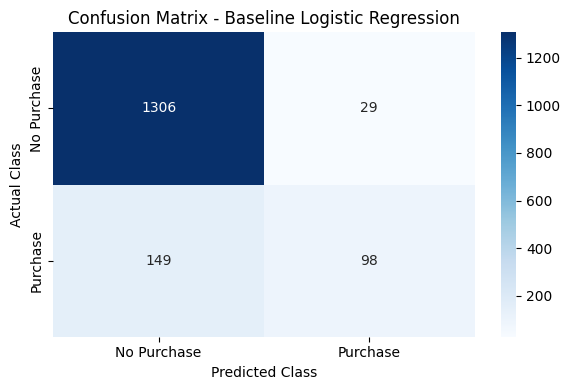

In [655]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### As we can see here, the model has:

### 1306 true negatives
### 98 true positives
### 29 false positives
### 149 false negatives

### IMPORTANT: with 149 false negatives, this is quite a lot of buyers that the model is missing!!

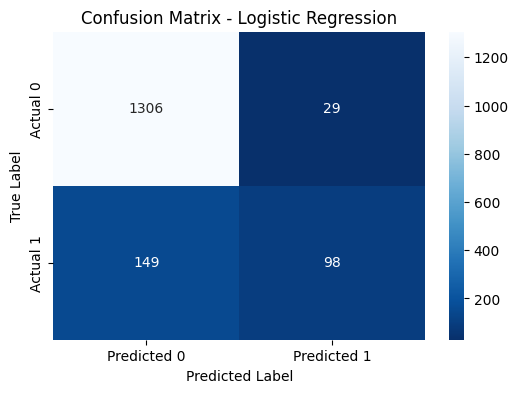

In [579]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues_r',
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### We will try to improve the model....

### This might be because our data is imbalanced

### We try to give class 1 more weight, because we have many more class 0 than class 1

In [580]:

log_reg_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

log_reg_balanced.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [581]:
y_val_pred_balanced = log_reg_balanced.predict(X_val_scaled)

y_val_proba_balanced = log_reg_balanced.predict_proba(X_val_scaled)[:, 1]


### As we can see below, after balancing the data we see that the false negatives have DECREASED from 149 to 62, which is a big improvement

In [ ]:


accuracy_balanced = accuracy_score(y_val, y_val_pred_balanced)
precision_balanced = precision_score(y_val, y_val_pred_balanced)
recall_balanced = recall_score(y_val, y_val_pred_balanced)
f1_balanced = f1_score(y_val, y_val_pred_balanced)
roc_auc_balanced = roc_auc_score(y_val, y_val_proba_balanced)


print("Accuracy:", round(accuracy_balanced, 4))
print("Precision:", round(precision_balanced, 4))
print("Recall:", round(recall_balanced, 4))
print("F1-score:", round(f1_balanced, 4))
print("ROC-AUC:", round(roc_auc_balanced, 4))


print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_balanced))


Accuracy: 0.8692
Precision: 0.5606
Recall: 0.749
F1-score: 0.6412
ROC-AUC: 0.9032

Confusion Matrix:
[[1190  145]
 [  62  185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1335
           1       0.56      0.75      0.64       247

    accuracy                           0.87      1582
   macro avg       0.76      0.82      0.78      1582
weighted avg       0.89      0.87      0.88      1582



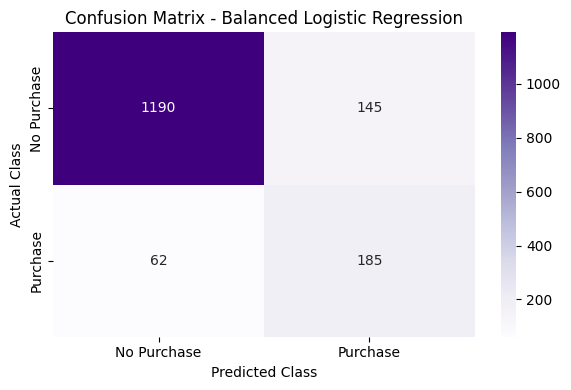

In [656]:
cm_balanced = confusion_matrix(y_val, y_val_pred_balanced)


plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()


---

### If we compare the models here, we can see that the first model gives fewer false positives

### while the balanced model is better at finding more potential buyers, and for our task this one fits better because we want to find as many potential buyers as possible

In [583]:

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Balanced Logistic Regression": [
        accuracy_balanced,
        precision_balanced,
        recall_balanced,
        f1_balanced,
        roc_auc_balanced
    ]
})

comparison_df = comparison_df.round(4)
display(comparison_df)


,Metric,Baseline Logistic Regression,Balanced Logistic Regression
0,Accuracy,0.8875,0.8692
1,Precision,0.7717,0.5606
2,Recall,0.3968,0.7490
3,F1-score,0.5241,0.6412
4,ROC-AUC,0.8961,0.9032


---

### Okay now we will do a GridSearchCV to find the best model with the best parameters

In [ ]:

log_reg = LogisticRegression(random_state=42, max_iter=1000)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"] # The model will take class imbalance into account
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [585]:
print("Best parameters:", grid_search.best_params_)

print("Best CV F1-score:", round(grid_search.best_score_, 4))


Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best CV F1-score: 0.6141


In [586]:
best_log_reg = grid_search.best_estimator_

y_val_pred_best = best_log_reg.predict(X_val_scaled)
y_val_proba_best = best_log_reg.predict_proba(X_val_scaled)[:, 1]


### as we can see below, the new model did not give any improvement

#### but it at least confirmed that the balanced logistic regression is the right direction

In [ ]:
accuracy_best = accuracy_score(y_val, y_val_pred_best)
precision_best = precision_score(y_val, y_val_pred_best)
recall_best = recall_score(y_val, y_val_pred_best)
f1_best = f1_score(y_val, y_val_pred_best)
roc_auc_best = roc_auc_score(y_val, y_val_proba_best)

print("Accuracy:", round(accuracy_best, 4))
print("Precision:", round(precision_best, 4))
print("Recall:", round(recall_best, 4))
print("F1-score:", round(f1_best, 4))
print("ROC-AUC:", round(roc_auc_best, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_best))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best))

Accuracy: 0.8679
Precision: 0.5572
Recall: 0.749
F1-score: 0.639
ROC-AUC: 0.9023

Confusion Matrix:
[[1188  147]
 [  62  185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1335
           1       0.56      0.75      0.64       247

    accuracy                           0.87      1582
   macro avg       0.75      0.82      0.78      1582
weighted avg       0.89      0.87      0.88      1582



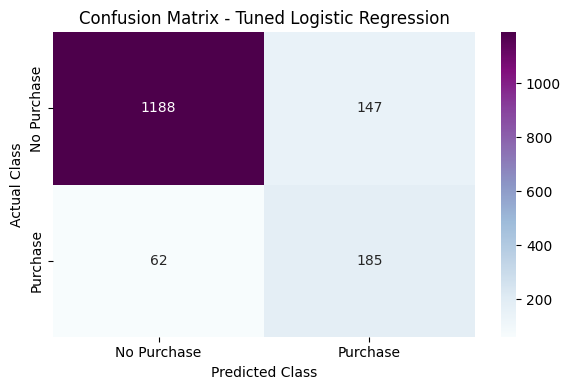

In [657]:
cm_best = confusion_matrix(y_val, y_val_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="BuPu",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

---

## we will now try another model, a RandomForest and see if it gives better results

### we create a baseline model

In [588]:

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [589]:
y_val_pred_rf = rf_model.predict(X_val)

y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]


In [590]:
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)
roc_auc_rf = roc_auc_score(y_val, y_val_proba_rf)

print("Accuracy:", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-score:", round(f1_rf, 4))
print("ROC-AUC:", round(roc_auc_rf, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf))

Accuracy: 0.909
Precision: 0.7562
Recall: 0.6154
F1-score: 0.6786
ROC-AUC: 0.9358

Confusion Matrix:
[[1286   49]
 [  95  152]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1335
           1       0.76      0.62      0.68       247

    accuracy                           0.91      1582
   macro avg       0.84      0.79      0.81      1582
weighted avg       0.90      0.91      0.91      1582



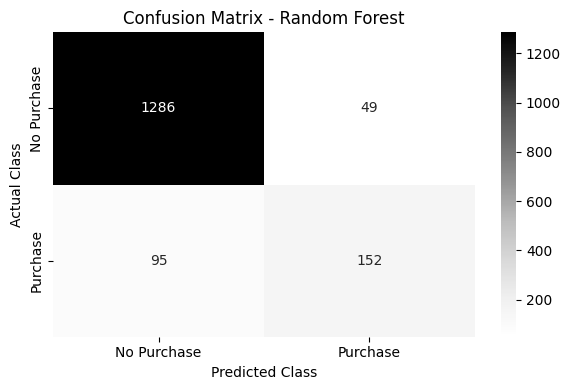

In [658]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greys",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## as we can see in the comparison, RandomForest has shown the best performance

In [591]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Balanced Logistic Regression": [
        accuracy_balanced,
        precision_balanced,
        recall_balanced,
        f1_balanced,
        roc_auc_balanced
    ],
    "Tuned Logistic Regression": [
        accuracy_best,
        precision_best,
        recall_best,
        f1_best,
        roc_auc_best
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

comparison_df = comparison_df.round(4)
display(comparison_df)


,Metric,Baseline Logistic Regression,Balanced Logistic Regression,Tuned Logistic Regression,Random Forest
0,Accuracy,0.8875,0.8692,0.8679,0.9090
1,Precision,0.7717,0.5606,0.5572,0.7562
2,Recall,0.3968,0.7490,0.7490,0.6154
3,F1-score,0.5241,0.6412,0.6390,0.6786
4,ROC-AUC,0.8961,0.9032,0.9023,0.9358


---

### We perform a GridSearchCV on RandomForest to find the best parameters

In [592]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [593]:
print("Best parameters:", grid_search_rf.best_params_)

print("Best CV F1-score:", round(grid_search_rf.best_score_, 4))


Best parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-score: 0.663


In [594]:
# Hämtar bästa Random Forest-modellen
best_rf = grid_search_rf.best_estimator_

# Prediktioner på validation set
y_val_pred_best_rf = best_rf.predict(X_val)
y_val_proba_best_rf = best_rf.predict_proba(X_val)[:, 1]


## here it shows a good improvement, especially because F1-score is important here when the classes are imbalanced.

In [595]:
accuracy_best_rf = accuracy_score(y_val, y_val_pred_best_rf)
precision_best_rf = precision_score(y_val, y_val_pred_best_rf)
recall_best_rf = recall_score(y_val, y_val_pred_best_rf)
f1_best_rf = f1_score(y_val, y_val_pred_best_rf)
roc_auc_best_rf = roc_auc_score(y_val, y_val_proba_best_rf)

print("Accuracy:", round(accuracy_best_rf, 4))
print("Precision:", round(precision_best_rf, 4))
print("Recall:", round(recall_best_rf, 4))
print("F1-score:", round(f1_best_rf, 4))
print("ROC-AUC:", round(roc_auc_best_rf, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best_rf))

Accuracy: 0.9033
Precision: 0.6926
Recall: 0.6842
F1-score: 0.6884
ROC-AUC: 0.9377

Confusion Matrix:
[[1260   75]
 [  78  169]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1335
           1       0.69      0.68      0.69       247

    accuracy                           0.90      1582
   macro avg       0.82      0.81      0.82      1582
weighted avg       0.90      0.90      0.90      1582



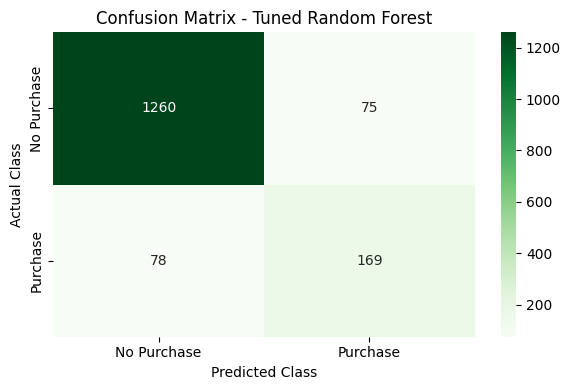

In [663]:
cm_best_rf = confusion_matrix(y_val, y_val_pred_best_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## As we can see here:

The table shows that the Tuned Random Forest is the best choice right now.

Why:

highest F1-score

highest ROC-AUC

strong and balanced precision and recall

better overall model compared to the logistic regression alternatives

In [596]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline Logistic Regression": [accuracy, precision, recall, f1, roc_auc],
    "Balanced Logistic Regression": [accuracy_balanced, precision_balanced, recall_balanced, f1_balanced, roc_auc_balanced],
    "Tuned Logistic Regression": [accuracy_best, precision_best, recall_best, f1_best, roc_auc_best],
    "Random Forest": [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf],
    "Tuned Random Forest": [accuracy_best_rf, precision_best_rf, recall_best_rf, f1_best_rf, roc_auc_best_rf]
})

comparison_df = comparison_df.round(4)
display(comparison_df)


,Metric,Baseline Logistic Regression,Balanced Logistic Regression,Tuned Logistic Regression,Random Forest,Tuned Random Forest
0,Accuracy,0.8875,0.8692,0.8679,0.9090,0.9033
1,Precision,0.7717,0.5606,0.5572,0.7562,0.6926
2,Recall,0.3968,0.7490,0.7490,0.6154,0.6842
3,F1-score,0.5241,0.6412,0.6390,0.6786,0.6884
4,ROC-AUC,0.8961,0.9032,0.9023,0.9358,0.9377


---

# But I still want to try one more model before moving on to the test set

## GradientBoostingClassifier

In [ ]:

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [598]:
y_val_pred_gb = gb_model.predict(X_val)

y_val_proba_gb = gb_model.predict_proba(X_val)[:, 1]


### as we can see below, so far the GradientBoostingClassifier shows

### better precision, better F1 and better ROC-AUC
### overall it is therefore the strongest model right now

In [ ]:
accuracy_gb = accuracy_score(y_val, y_val_pred_gb)
precision_gb = precision_score(y_val, y_val_pred_gb)
recall_gb = recall_score(y_val, y_val_pred_gb)
f1_gb = f1_score(y_val, y_val_pred_gb)
roc_auc_gb = roc_auc_score(y_val, y_val_proba_gb)

print("Accuracy:", round(accuracy_gb, 4))
print("Precision:", round(precision_gb, 4))
print("Recall:", round(recall_gb, 4))
print("F1-score:", round(f1_gb, 4))
print("ROC-AUC:", round(roc_auc_gb, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_gb))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_gb))

Accuracy: 0.9115
Precision: 0.7536
Recall: 0.6437
F1-score: 0.6943
ROC-AUC: 0.9413

Confusion Matrix:
[[1283   52]
 [  88  159]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1335
           1       0.75      0.64      0.69       247

    accuracy                           0.91      1582
   macro avg       0.84      0.80      0.82      1582
weighted avg       0.91      0.91      0.91      1582



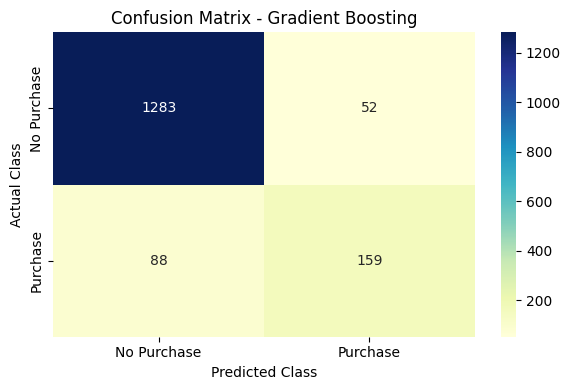

In [664]:
cm_gb = confusion_matrix(y_val, y_val_pred_gb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [600]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline Logistic Regression": [accuracy, precision, recall, f1, roc_auc],
    "Balanced Logistic Regression": [accuracy_balanced, precision_balanced, recall_balanced, f1_balanced, roc_auc_balanced],
    "Tuned Logistic Regression": [accuracy_best, precision_best, recall_best, f1_best, roc_auc_best],
    "Random Forest": [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf],
    "Tuned Random Forest": [accuracy_best_rf, precision_best_rf, recall_best_rf, f1_best_rf, roc_auc_best_rf],
    "Gradient Boosting": [accuracy_gb, precision_gb, recall_gb, f1_gb, roc_auc_gb]
}).round(4)

display(comparison_df)


,Metric,Baseline Logistic Regression,Balanced Logistic Regression,Tuned Logistic Regression,Random Forest,Tuned Random Forest,Gradient Boosting
0,Accuracy,0.8875,0.8692,0.8679,0.9090,0.9033,0.9115
1,Precision,0.7717,0.5606,0.5572,0.7562,0.6926,0.7536
2,Recall,0.3968,0.7490,0.7490,0.6154,0.6842,0.6437
3,F1-score,0.5241,0.6412,0.6390,0.6786,0.6884,0.6943
4,ROC-AUC,0.8961,0.9032,0.9023,0.9358,0.9377,0.9413


## We run GridSearchCV on this model to find the best parameters and evaluate it with them, and check if it is still the best model!

In [601]:
gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [ ]:
print("Best parameters:", grid_search_gb.best_params_)

print("Best CV F1-score:", round(grid_search_gb.best_score_, 4))


Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-score: 0.6436


In [603]:
best_gb = grid_search_gb.best_estimator_

y_val_pred_best_gb = best_gb.predict(X_val)
y_val_proba_best_gb = best_gb.predict_proba(X_val)[:, 1]


### As we can see here after tuning the model:

### GridSearchCV did not find a better variant for the validation set

### the standard Gradient Boosting model is still the best among all the models we have tested

In [604]:

accuracy_best_gb = accuracy_score(y_val, y_val_pred_best_gb)
precision_best_gb = precision_score(y_val, y_val_pred_best_gb)
recall_best_gb = recall_score(y_val, y_val_pred_best_gb)
f1_best_gb = f1_score(y_val, y_val_pred_best_gb)
roc_auc_best_gb = roc_auc_score(y_val, y_val_proba_best_gb)

print("Accuracy:", round(accuracy_best_gb, 4))
print("Precision:", round(precision_best_gb, 4))
print("Recall:", round(recall_best_gb, 4))
print("F1-score:", round(f1_best_gb, 4))
print("ROC-AUC:", round(roc_auc_best_gb, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_best_gb))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best_gb))


Accuracy: 0.9052
Precision: 0.7343
Recall: 0.6154
F1-score: 0.6696
ROC-AUC: 0.9407

Confusion Matrix:
[[1280   55]
 [  95  152]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1335
           1       0.73      0.62      0.67       247

    accuracy                           0.91      1582
   macro avg       0.83      0.79      0.81      1582
weighted avg       0.90      0.91      0.90      1582



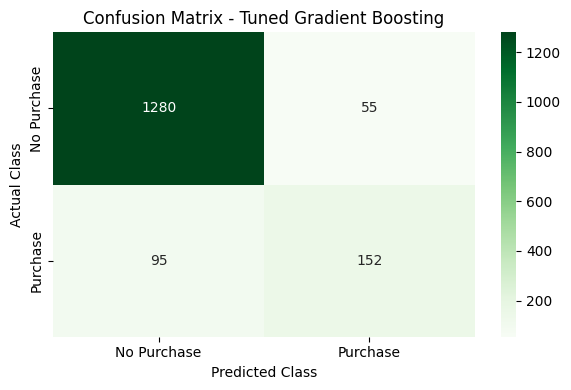

In [666]:
cm_best_gb = confusion_matrix(y_val, y_val_pred_best_gb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_best_gb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

---

## So far we have tested different models and compared them to find the most promising one, which is now: Gradient Boosting.

### But we are not done yet, we know that our data was class imbalanced and so far we have only tried balancing it in one way: class_weight="balanced"

##

### The plan now is to test our best model with different ways of balancing the data to improve it even further

### We will test Gradient Boosting with:

### - RandomOverSampler

### - SMOTE

### - RandomUnderSampler

In [606]:
ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)


### As we can see in the comparison, we have balanced the data using oversampling, which copies the minority class to reach balance

In [607]:
print(y_train.value_counts())
print(y_train_ros.value_counts())


Revenue
0    6231
1    1150
Name: count, dtype: int64
Revenue
0    6231
1    6231
Name: count, dtype: int64


In [608]:

gb_ros = GradientBoostingClassifier(random_state=42)

gb_ros.fit(X_train_ros, y_train_ros)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [609]:
y_val_pred_ros = gb_ros.predict(X_val)

y_val_proba_ros = gb_ros.predict_proba(X_val)[:, 1]


### As we can see below:

#### RandomOverSampler + Gradient Boosting resulted in:

#### - the model now finds many more actual buyers

#### - but it also produces many more false positives

In [611]:
accuracy_ros = accuracy_score(y_val, y_val_pred_ros)
precision_ros = precision_score(y_val, y_val_pred_ros)
recall_ros = recall_score(y_val, y_val_pred_ros)
f1_ros = f1_score(y_val, y_val_pred_ros)
roc_auc_ros = roc_auc_score(y_val, y_val_proba_ros)

print("Accuracy:", round(accuracy_ros, 4))
print("Precision:", round(precision_ros, 4))
print("Recall:", round(recall_ros, 4))
print("F1-score:", round(f1_ros, 4))
print("ROC-AUC:", round(roc_auc_ros, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_ros))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_ros))

Accuracy: 0.8717
Precision: 0.5576
Recall: 0.8623
F1-score: 0.6773
ROC-AUC: 0.9401

Confusion Matrix:
[[1166  169]
 [  34  213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      1335
           1       0.56      0.86      0.68       247

    accuracy                           0.87      1582
   macro avg       0.76      0.87      0.80      1582
weighted avg       0.91      0.87      0.88      1582



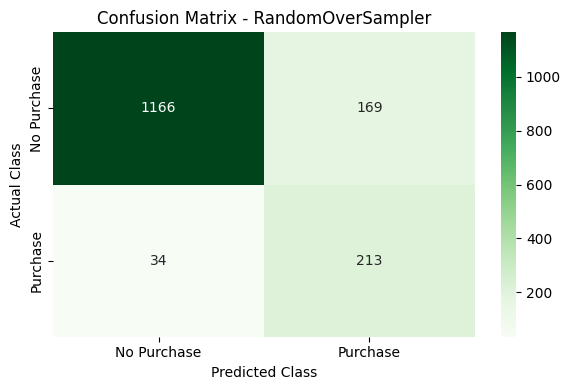

In [668]:
cm_ros = confusion_matrix(y_val, y_val_pred_ros)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_ros,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - RandomOverSampler")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

---

### We now test the next method, SMOTE:

#### which does:

##### - it looks at real observations in the minority class

##### - finds similar neighbors among them

##### - creates new data points “between” these observations

In [613]:

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [614]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Revenue
0    6231
1    1150
Name: count, dtype: int64
Revenue
0    6231
1    6231
Name: count, dtype: int64


In [615]:

gb_smote = GradientBoostingClassifier(random_state=42)

gb_smote.fit(X_train_smote, y_train_smote)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [616]:
y_val_pred_smote = gb_smote.predict(X_val)

y_val_proba_smote = gb_smote.predict_proba(X_val)[:, 1]


## Okay so so far:

### SMOTE + Gradient Boosting is better than both the class_weight variant and RandomOverSampler, if we look at the balance between precision and recall

In [618]:
accuracy_smote = accuracy_score(y_val, y_val_pred_smote)
precision_smote = precision_score(y_val, y_val_pred_smote)
recall_smote = recall_score(y_val, y_val_pred_smote)
f1_smote = f1_score(y_val, y_val_pred_smote)
roc_auc_smote = roc_auc_score(y_val, y_val_proba_smote)

print("Accuracy:", round(accuracy_smote, 4))
print("Precision:", round(precision_smote, 4))
print("Recall:", round(recall_smote, 4))
print("F1-score:", round(f1_smote, 4))
print("ROC-AUC:", round(roc_auc_smote, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_smote))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_smote))

Accuracy: 0.9027
Precision: 0.6691
Recall: 0.7449
F1-score: 0.705
ROC-AUC: 0.9319

Confusion Matrix:
[[1244   91]
 [  63  184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1335
           1       0.67      0.74      0.70       247

    accuracy                           0.90      1582
   macro avg       0.81      0.84      0.82      1582
weighted avg       0.91      0.90      0.90      1582



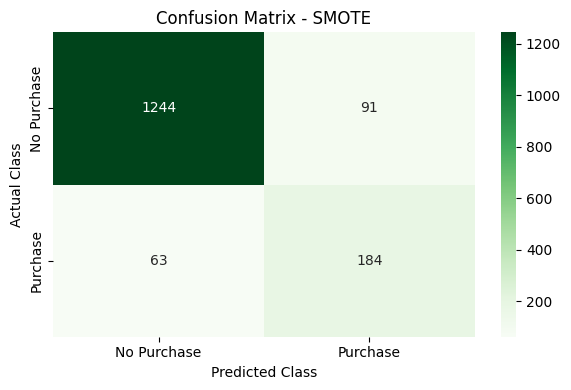

In [669]:
cm_smote = confusion_matrix(y_val, y_val_pred_smote)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - SMOTE")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

---

### We test the last method: RandomUnderSampler

#### which randomly reduces the majority class until it is balanced with the minority class

In [620]:
rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)


In [621]:
print(y_train.value_counts())
print(y_train_rus.value_counts())

Revenue
0    6231
1    1150
Name: count, dtype: int64
Revenue
0    1150
1    1150
Name: count, dtype: int64


In [623]:
gb_rus = GradientBoostingClassifier(random_state=42)

gb_rus.fit(X_train_rus, y_train_rus)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [624]:
y_val_pred_rus = gb_rus.predict(X_val)

y_val_proba_rus = gb_rus.predict_proba(X_val)[:, 1]


### Okay as we can see in the following cell, this combination, like Oversampler, became better at finding real buyers but also produces more false positive predictions

In [625]:
accuracy_rus = accuracy_score(y_val, y_val_pred_rus)
precision_rus = precision_score(y_val, y_val_pred_rus)
recall_rus = recall_score(y_val, y_val_pred_rus)
f1_rus = f1_score(y_val, y_val_pred_rus)
roc_auc_rus = roc_auc_score(y_val, y_val_proba_rus)

print("Accuracy:", round(accuracy_rus, 4))
print("Precision:", round(precision_rus, 4))
print("Recall:", round(recall_rus, 4))
print("F1-score:", round(f1_rus, 4))
print("ROC-AUC:", round(roc_auc_rus, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rus))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rus))


Accuracy: 0.8647
Precision: 0.5403
Recall: 0.8947
F1-score: 0.6738
ROC-AUC: 0.9345

Confusion Matrix:
[[1147  188]
 [  26  221]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91      1335
           1       0.54      0.89      0.67       247

    accuracy                           0.86      1582
   macro avg       0.76      0.88      0.79      1582
weighted avg       0.91      0.86      0.88      1582



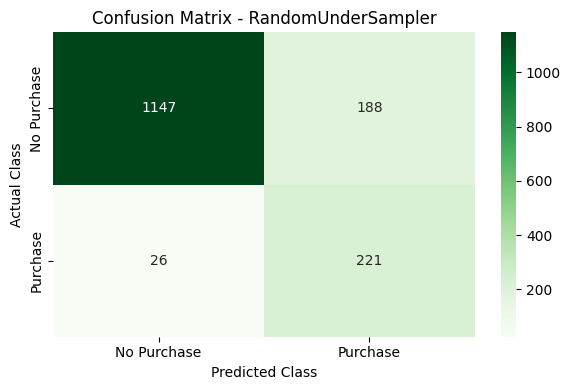

In [670]:
cm_rus = confusion_matrix(y_val, y_val_pred_rus)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rus,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - RandomUnderSampler")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

----

## We need to compare the methods we have tested and analyze them a bit more

In [632]:
imbalance_comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Class Weight": [
        accuracy_balanced,
        precision_balanced,
        recall_balanced,
        f1_balanced,
        roc_auc_balanced
    ],
    "RandomOverSampler": [
        accuracy_ros,
        precision_ros,
        recall_ros,
        f1_ros,
        roc_auc_ros
    ],
    "SMOTE": [
        accuracy_smote,
        precision_smote,
        recall_smote,
        f1_smote,
        roc_auc_smote
    ],
    "RandomUnderSampler": [
        accuracy_rus,
        precision_rus,
        recall_rus,
        f1_rus,
        roc_auc_rus
    ]
}).round(4)

display(
    imbalance_comparison_df.style.highlight_max(
        subset=["Class Weight", "RandomOverSampler", "SMOTE", "RandomUnderSampler"],
        axis=1,
        color="green"
    )
)


,Metric,Class Weight,RandomOverSampler,SMOTE,RandomUnderSampler
0,Accuracy,0.869200,0.871700,0.902700,0.864700
1,Precision,0.560600,0.557600,0.669100,0.540300
2,Recall,0.749000,0.862300,0.744900,0.894700
3,F1-score,0.641200,0.677300,0.705000,0.673800
4,ROC-AUC,0.903200,0.940100,0.931900,0.934500


---

## Right now we already have a strong candidate, but I want to be more certain before locking the final model

### I want to experiment with it a bit more and see if we can improve it further in any way

### We will fine-tune the best combination we currently have, meaning SMOTE + Gradient Boosting, with more parameters or a wider search space.

In [638]:

gb_smote_base = GradientBoostingClassifier(random_state=42)

param_grid_gb_smote_small = {
    "n_estimators": [100, 150],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0]
}

grid_search_gb_smote_small = GridSearchCV(
    estimator=gb_smote_base,
    param_grid=param_grid_gb_smote_small,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid_search_gb_smote_small.fit(X_train_smote, y_train_smote)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END learning_rate=0.03, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.2s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.2s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.2s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.4s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=150, subsample=0.8; total time=   1.8s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=150, subsample=0.8; total time=   1.9s
[CV] END learning_rate=0.03, max_depth=2, n_estimators=150, subsample=0.8; total time=   2.1s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.8s

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3], 'n_estimators': [100, 150], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [639]:
print("Best parameters:", grid_search_gb_smote_small.best_params_)
print("Best CV F1-score:", round(grid_search_gb_smote_small.best_score_, 4))

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV F1-score: 0.9061


In [640]:
best_gb_smote_small = grid_search_gb_smote_small.best_estimator_

y_val_pred_best_smote = best_gb_smote_small.predict(X_val)
y_val_proba_best_smote = best_gb_smote_small.predict_proba(X_val)[:, 1]


### This actually became our best model so far according to F1-score, which is high only when both precision and recall are reasonably good.

.

### Compared to the previous SMOTE + Gradient Boosting:

#### - F1-score increased from 0.7050 to 0.7085
#### - Recall increased from 0.7449 to 0.7773
#### - Precision decreased slightly from 0.6691 to 0.6508
#### - ROC-AUC decreased slightly from 0.9319 to 0.9310

-
-
-

#### - the model finds more real buyers than before
#### - it loses a bit of precision
#### - but overall the balance improved, which is why the F1-score increased

In [641]:

accuracy_best_smote = accuracy_score(y_val, y_val_pred_best_smote)
precision_best_smote = precision_score(y_val, y_val_pred_best_smote)
recall_best_smote = recall_score(y_val, y_val_pred_best_smote)
f1_best_smote = f1_score(y_val, y_val_pred_best_smote)
roc_auc_best_smote = roc_auc_score(y_val, y_val_proba_best_smote)

print("Accuracy:", round(accuracy_best_smote, 4))
print("Precision:", round(precision_best_smote, 4))
print("Recall:", round(recall_best_smote, 4))
print("F1-score:", round(f1_best_smote, 4))
print("ROC-AUC:", round(roc_auc_best_smote, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_best_smote))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best_smote))


Accuracy: 0.9001
Precision: 0.6508
Recall: 0.7773
F1-score: 0.7085
ROC-AUC: 0.931

Confusion Matrix:
[[1232  103]
 [  55  192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1335
           1       0.65      0.78      0.71       247

    accuracy                           0.90      1582
   macro avg       0.80      0.85      0.82      1582
weighted avg       0.91      0.90      0.90      1582



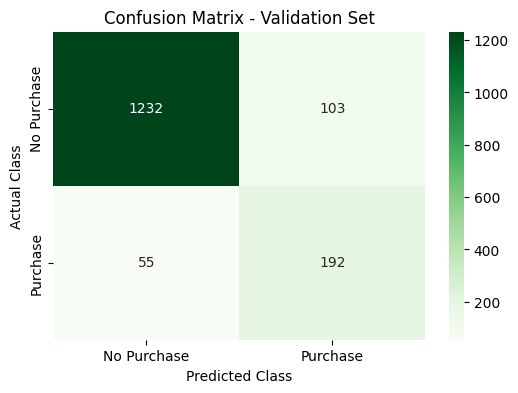

In [671]:

cm_best_smote = confusion_matrix(y_val, y_val_pred_best_smote)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_best_smote,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


## So far we have already tested several model types
## tested multiple ways of handling imbalanced data
## done tuning
## compared the results systematically on the validation set

## - And according to our work, SMOTE + tuned Gradient Boosting is the best model we could find 

#### - it has the highest F1-score on the validation set

#### - it has strong recall, which is important when the goal is to find buyers

#### - the precision is still acceptable

---



# FINAL EVALUATION

### Now we do the final evaluation on the TEST set

In [642]:
y_test_pred_best_smote = best_gb_smote_small.predict(X_test)
y_test_proba_best_smote = best_gb_smote_small.predict_proba(X_test)[:, 1]


## As we can see in the following cell:

#### - The most important business aspect is that the model identifies about 75% of actual purchases, which is strong for an imbalanced dataset. 

### - At the same time, precision is more moderate, which means that some sessions will be flagged as purchases even though they do not lead to a purchase.

In [644]:
accuracy_test_smote = accuracy_score(y_test, y_test_pred_best_smote)
precision_test_smote = precision_score(y_test, y_test_pred_best_smote)
recall_test_smote = recall_score(y_test, y_test_pred_best_smote)
f1_test_smote = f1_score(y_test, y_test_pred_best_smote)
roc_auc_test_smote = roc_auc_score(y_test, y_test_proba_best_smote)

print("Accuracy:", round(accuracy_test_smote, 4))
print("Precision:", round(precision_test_smote, 4))
print("Recall:", round(recall_test_smote, 4))
print("F1-score:", round(f1_test_smote, 4))
print("ROC-AUC:", round(roc_auc_test_smote, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_best_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_best_smote))


Accuracy: 0.8843
Precision: 0.6033
Recall: 0.748
F1-score: 0.6679
ROC-AUC: 0.9268

Confusion Matrix:
[[1215  121]
 [  62  184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1336
           1       0.60      0.75      0.67       246

    accuracy                           0.88      1582
   macro avg       0.78      0.83      0.80      1582
weighted avg       0.90      0.88      0.89      1582



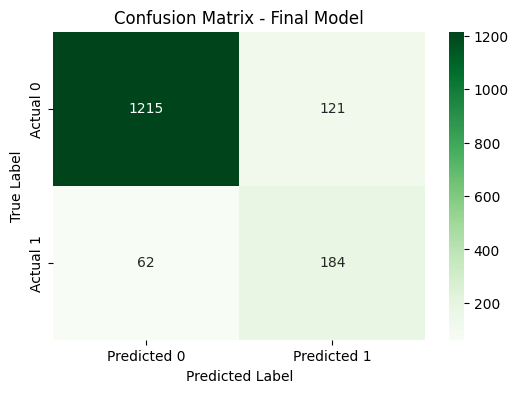

In [651]:

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_test_smote,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


---

# CONCLUSION

### - The purpose of the task was to build a model that can predict whether a customer session will lead to a purchase or not. 

### - After testing several different models and different ways of handling imbalanced data, I found that Gradient Boosting together with SMOTE and tuned parameters gave the best results.

### - The final model performed well on the test data. 

### - It achieved an accuracy of 88.43% 

### - and managed to identify about 74.8% of the sessions that actually led to a purchase. 

### - This shows that the model is quite good at capturing customers with a high probability of buying.

### - At the same time, there are some limitations:

### - The model’s precision was 60.33%, which means that not all sessions predicted as purchases actually result in a purchase in reality. 

### - Therefore, the model can be a good support tool for the company, but it should not be used without careful consideration.

---


---

<h1 style="color:aqua">Report: Prediction of Purchase Intention in Customer Sessions</h1>

---

<h2 style="color:aqua">Introduction</h2>
<p>
The purpose of this work was to build a model that can predict whether a customer session will lead to a purchase or not. 
We want to use the results in <b style="color:yellow">real time</b> to quickly identify customers with a high probability of buying. 
In the future, this can help the model support better decision-making and improve the customer experience.
</p>

<p>
This is a <b style="color:yellow">binary classification problem</b>, since the model predicts one of two possible outcomes: 
<b>purchase</b> or <b>no purchase</b>.
</p>

---

<h2 style="color:aqua">Data and Target Variable</h2>
<p>
The dataset contains information about previous customer sessions on an e-commerce website. Each row represents a session and includes different variables describing customer behavior during the visit, such as:
</p>

<ul>
  <li>number of pages visited</li>
  <li>time spent on different types of pages</li>
  <li>bounce rate</li>
  <li>exit rate</li>
  <li>traffic source</li>
  <li>whether the session occurred on a weekend</li>
</ul>

<p>
The target variable in the analysis is <b style="color:green">Revenue</b>, where:
</p>

<ul>
  <li><b>1</b> means the session resulted in a purchase</li>
  <li><b>0</b> means the session did not result in a purchase</li>
</ul>

/var/folders/90/z32x2x9j2znbkvp6zybwdj9r0000gn/T/ipykernel_23916/703452268.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Revenue", data=df, palette="Blues")


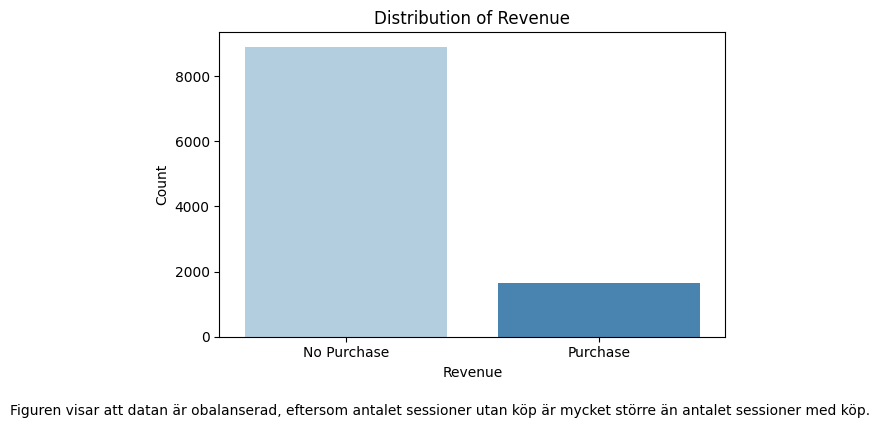

In [681]:

plt.figure(figsize=(6, 4))
sns.countplot(x="Revenue", data=df, palette="Blues")

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.figtext(
    0.5, -0.05,
    "Figuren visar att datan är obalanserad, eftersom antalet sessioner utan köp är mycket större än antalet sessioner med köp.",
    ha="center",
    fontsize=10)
plt.tight_layout()
plt.show()


---

<p>
An important observation was that the data was <b style="color:yellow">imbalanced</b>. Around <b>84 %</b> of the sessions did not lead to a purchase, while approximately <b>16 %</b> did lead to a purchase. 
This meant that <b>accuracy</b> alone was not enough as a metric to evaluate the models.
</p>

---

<h2 style="color:aqua">Data Preparation</h2>
<p>
Before modeling started, the data was cleaned. Missing values were removed and incorrect values in some columns were corrected or excluded. 
For example, invalid values were detected in:
</p>

<ul>
  <li><code>Weekend</code></li>
  <li><code>Month</code></li>
  <li><code>BounceRates</code></li>
  <li><code>Administrative</code></li>
</ul>

<p>
Since some of these variables represent <b>ratios</b> or <b>counts</b>, negative or unrealistic values could not be used and were therefore removed.
</p>

<p>
The <code>Month</code> column was recoded into numerical values and also transformed using <b style="color:#548235;">cyclical encoding</b> using:
</p>

<ul>
  <li><code>Month_sin</code></li>
  <li><code>Month_cos</code></li>
</ul>

<p>
<code>VisitorType</code> was encoded using <b>one-hot encoding</b>. Duplicates in the data were also identified and removed.
</p>

<p>
After cleaning, the dataset consisted of <b style="color:green">10,545 observations</b> and <b>21 variables</b>, with no missing values.
</p>

---

<h2 style="color:aqua">Exploratory Data Analysis</h2>
<p>
After data preparation, an exploratory analysis was performed to better understand the data. It showed that some variables had a clearer relationship with purchases than others.
</p>

/var/folders/90/z32x2x9j2znbkvp6zybwdj9r0000gn/T/ipykernel_23916/753148249.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Revenue", y="PageValues", data=df, palette="Set2")


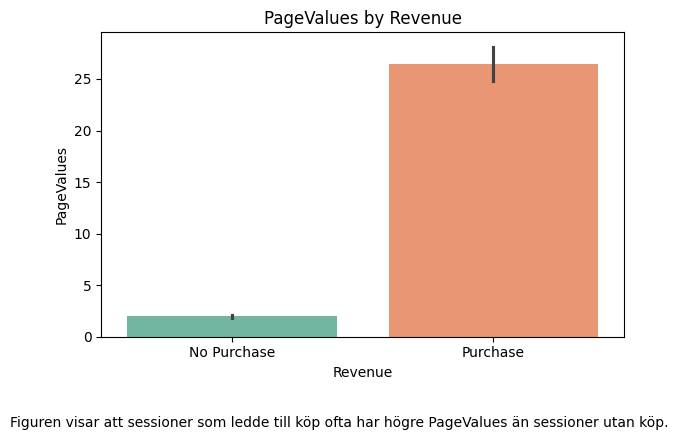

In [ ]:

plt.figure(figsize=(6, 4))
sns.barplot(x="Revenue", y="PageValues", data=df, palette="Set2")

plt.title("PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("PageValues")
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.figtext(
    0.5, -0.08,
    "Figuren visar att sessioner som ledde till köp ofta har högre PageValues än sessioner utan köp.",
    ha="center",
    fontsize=10)
plt.tight_layout()
plt.show()


---

<p style="font-size:18px;">
For example, we observed that customers who actually made a purchase often had higher values in <code>PageValues</code> and spent more time on product-related pages. 
Variables such as <code>BounceRates</code> and <code>ExitRates</code> also showed differences between purchases and non-purchases. 
This suggests that customer behavior during the session is clearly linked to the likelihood of making a purchase.
</p>

/var/folders/90/z32x2x9j2znbkvp6zybwdj9r0000gn/T/ipykernel_23916/3075379497.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Revenue", y="BounceRates", data=df, palette="Set3")


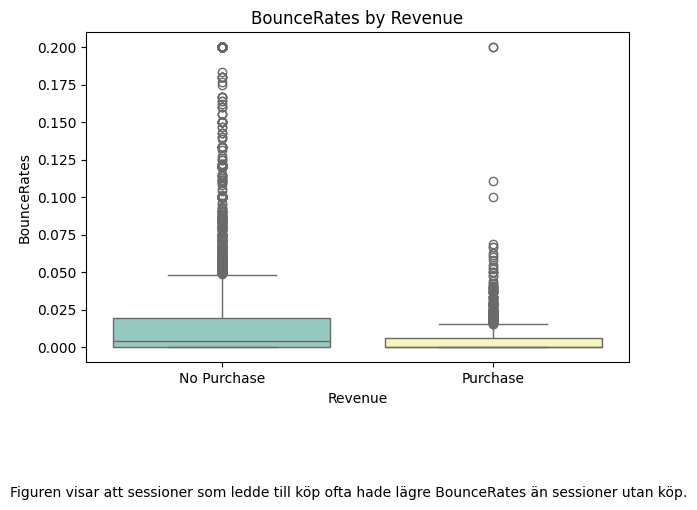

In [683]:

plt.figure(figsize=(7, 5))
sns.boxplot(x="Revenue", y="BounceRates", data=df, palette="Set3")

plt.title("BounceRates by Revenue")
plt.xlabel("Revenue")
plt.ylabel("BounceRates")
plt.xticks([0, 1], ["No Purchase", "Purchase"])

plt.figtext(
    0.5, -0.05,
    "Figuren visar att sessioner som ledde till köp ofta hade lägre BounceRates än sessioner utan köp.",
    ha="center",
    fontsize=10
)

plt.subplots_adjust(bottom=0.22)
plt.show()


---

<p>
Analyses were also performed on categorical variables, such as:
</p>

<ul>
  <li>month</li>

  <li>weekend</li>
</ul>

<p>
to see whether the purchase rate varied between different groups.
</p>

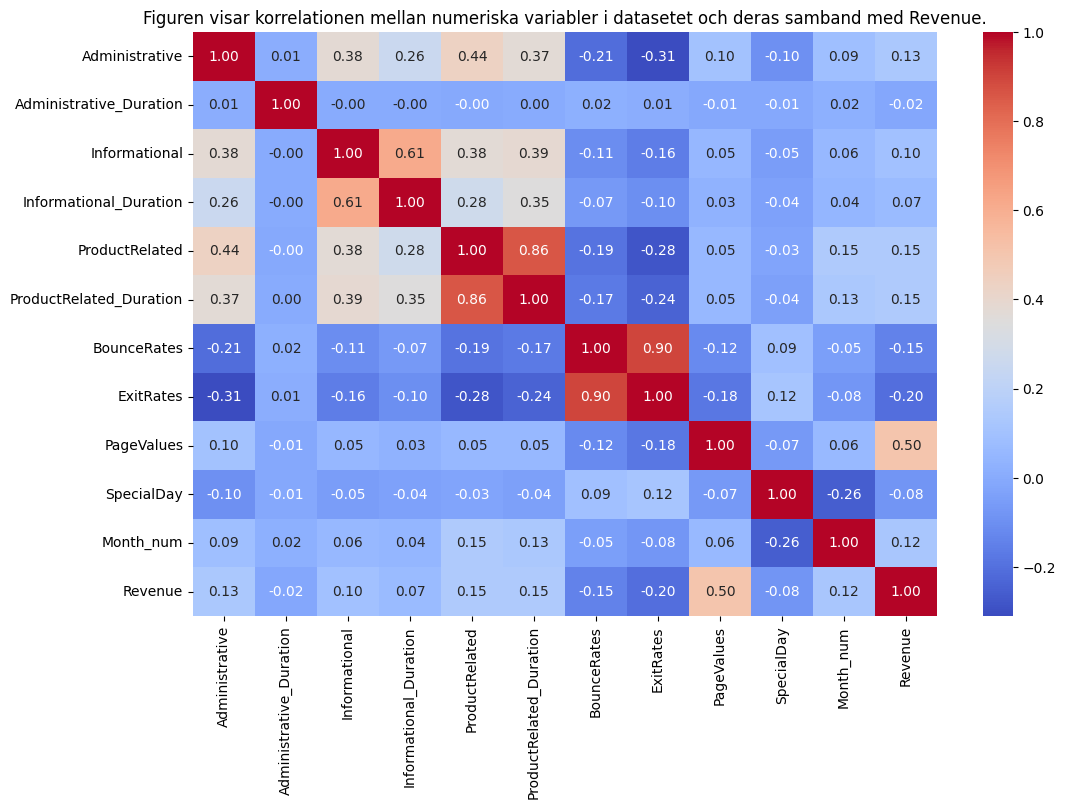

In [685]:

numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month_num",
    "Revenue"
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Figuren visar korrelationen mellan numeriska variabler i datasetet och deras samband med Revenue.")


plt.subplots_adjust(bottom=0.15)
plt.show()


---

---

<h2 style="color:aqua">Modeling</h2>
<p>
Several different models were tested in the project. First, <b>Logistic Regression</b> was used as a simple baseline model. After that, a balanced version of Logistic Regression was tested, where more weight was given to the positive class. Then the following models were also tested:
</p>

<ul>
  <li><b>Random Forest</b></li>
  <li><b>Gradient Boosting</b></li>
</ul>

<p>
The models were compared using several metrics:
</p>

<ul>
  <li><b>Accuracy</b></li>
  <li><b>Precision</b></li>
  <li><b>Recall</b></li>
  <li><b>F1-score</b></li>
  <li><b>ROC-AUC</b></li>
</ul>

<p>
Since the data was imbalanced, <b style="color:green">F1-score</b> became especially important, as it combines precision and recall and therefore provides a more fair view of the model’s performance.
</p>

/var/folders/90/z32x2x9j2znbkvp6zybwdj9r0000gn/T/ipykernel_23916/2209630854.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_f1_df, x="F1-score", y="Model", palette="viridis")


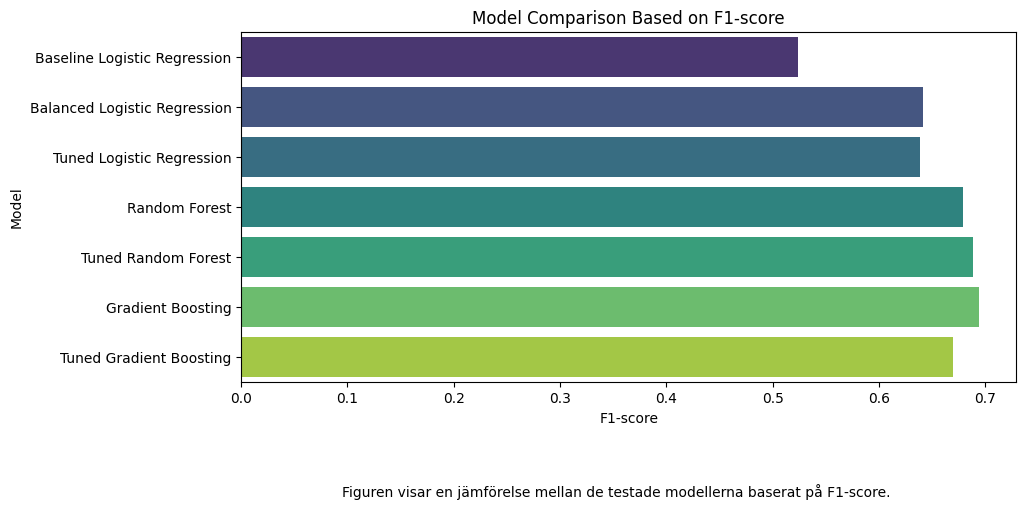

In [687]:

model_f1_df = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "Tuned Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "F1-score": [
        f1,
        f1_balanced,
        f1_best,
        f1_rf,
        f1_best_rf,
        f1_gb,
        f1_best_gb
    ]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=model_f1_df, x="F1-score", y="Model", palette="viridis")

plt.title("Model Comparison Based on F1-score")
plt.xlabel("F1-score")
plt.ylabel("Model")

plt.figtext(
    0.5, -0.05,
    "Figuren visar en jämförelse mellan de testade modellerna baserat på F1-score.",
    ha="center",
    fontsize=10
)

plt.subplots_adjust(bottom=0.18)
plt.show()


---

---

<h2 style="color:aqua">Handling Imbalanced Data</h2>
<p>
Since the target variable was imbalanced, several different methods were tested to improve the model’s ability to detect purchases:
</p>

<ul>
  <li><code>class_weight</code></li>
  <li><code>RandomOverSampler</code></li>
  <li><code>SMOTE</code></li>
  <li><code>RandomUnderSampler</code></li>
</ul>

<p>
These methods were tested together with the most promising model, <b>Gradient Boosting</b>. The results showed that <b style="color:#548235;">SMOTE</b> provided the best balance between precision and recall. 
Therefore, SMOTE was selected as the final method for handling the imbalance in the data.
</p>

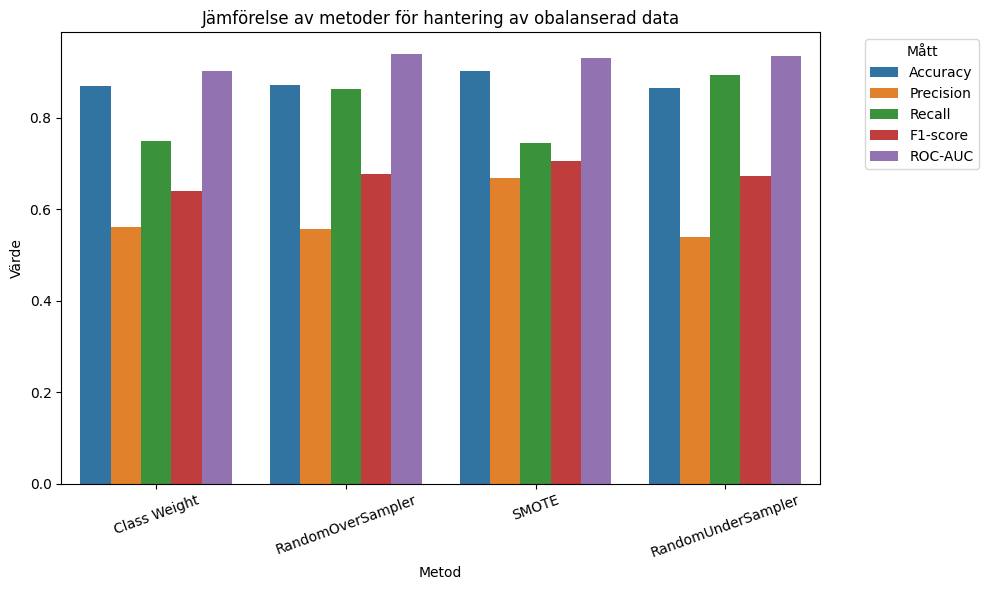

In [694]:

plot_df = imbalance_comparison_df.set_index("Metric").T.reset_index()
plot_df = plot_df.rename(columns={"index": "Metod"})

plot_df_melted = plot_df.melt(id_vars="Metod", var_name="Mått", value_name="Värde")

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df_melted,
    x="Metod",
    y="Värde",
    hue="Mått"
)

plt.title("Jämförelse av metoder för hantering av obalanserad data")
plt.xlabel("Metod")
plt.ylabel("Värde")
plt.xticks(rotation=20)

plt.legend(title="Mått", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---

---

<h2 style="color:aqua">Final Model Selection</h2>
<p>
After comparing models and balancing methods, <b style="color:green">SMOTE + tuned Gradient Boosting</b> was selected as the final model. 
This model provided the best overall balance between identifying real buyers and avoiding too many false positive predictions.
</p>

<p>
The model was also fine-tuned using a small <b>Grid Search</b> to find better parameter settings. 
This resulted in a slight improvement compared to the standard SMOTE version of Gradient Boosting.
</p>

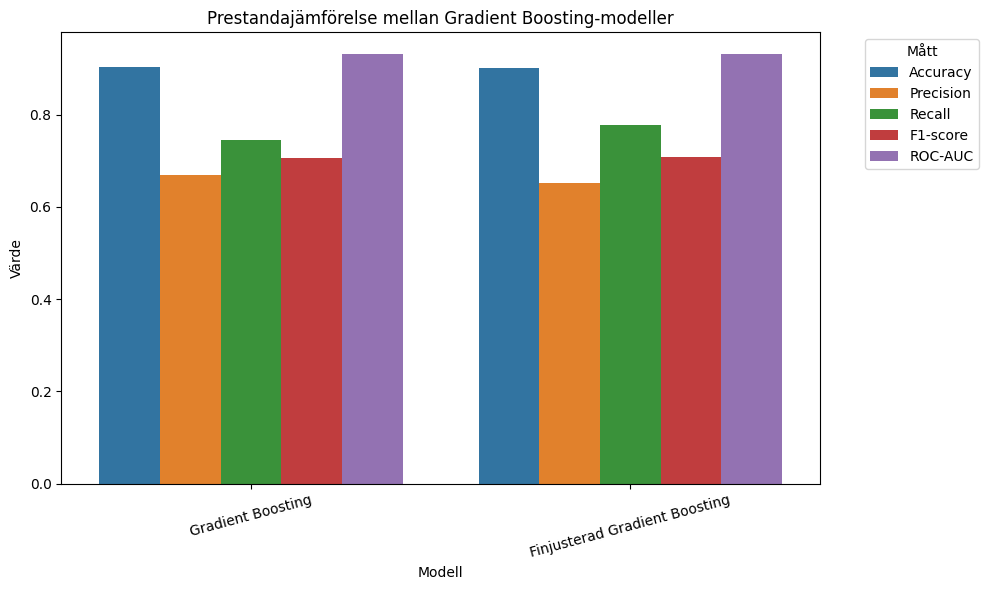

In [696]:

model_comparison_df = pd.DataFrame({
    "Mått": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Gradient Boosting": [
        accuracy_smote,
        precision_smote,
        recall_smote,
        f1_smote,
        roc_auc_smote
    ],
    "Finjusterad Gradient Boosting": [
        accuracy_best_smote,
        precision_best_smote,
        recall_best_smote,
        f1_best_smote,
        roc_auc_best_smote
    ]
}).round(4)

plot_df = model_comparison_df.set_index("Mått").T.reset_index()
plot_df = plot_df.rename(columns={"index": "Modell"})

plot_df_melted = plot_df.melt(id_vars="Modell", var_name="Mått", value_name="Värde")

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df_melted,
    x="Modell",
    y="Värde",
    hue="Mått"
)

plt.title("Prestandajämförelse mellan Gradient Boosting-modeller")
plt.xlabel("Modell")
plt.ylabel("Värde")
plt.xticks(rotation=15)

plt.legend(title="Mått", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---

---

<h2 style="color:aqua">Final Results</h2>
<p>
The final model was evaluated on the test data and produced the following results:
</p>

<ul>
  <li><b>Accuracy:</b> <span style="color:white">88.43%</span></li>
  <li><b>Precision:</b> <span style="color:white">60.33%</span></li>
  <li><b>Recall:</b> <span style="color:white">74.80%</span></li>
  <li><b>F1-score:</b> <span style="color:white">66.79%</span></li>
  <li><b>ROC-AUC:</b> <span style="color:white">92.68%</span></li>
</ul>

<p>
The results show that the model managed to identify around <b style="color:#548235;">75%</b> of all actual purchases. This means the model is fairly good at detecting customers who are likely to buy. 
At the same time, the precision shows that not all sessions predicted as purchases actually result in a purchase. There are still some <b style="color:green">false positives</b>.
</p>

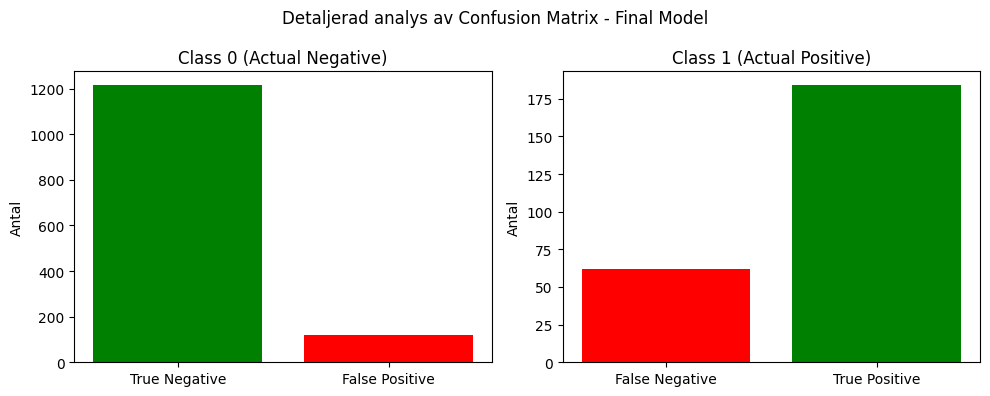

In [703]:

tn, fp, fn, tp = cm_test_smote.ravel()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["True Negative", "False Positive"], [tn, fp], color=["green", "red"])
axes[0].set_title("Class 0 (Actual Negative)")
axes[0].set_ylabel("Antal")

axes[1].bar(["False Negative", "True Positive"], [fn, tp], color=["red", "green"])
axes[1].set_title("Class 1 (Actual Positive)")
axes[1].set_ylabel("Antal")

plt.suptitle("Detaljerad analys av Confusion Matrix - Final Model")

plt.tight_layout()
plt.show()

---

---

<h2 style="color:aqua">Conclusion</h2>
<p>
In summary, the analysis shows that it is possible to predict purchase intention with fairly good accuracy based on historical customer session data. 
The best performing model in this work was <b style="color:green;">Gradient Boosting combined with SMOTE and tuned parameters</b>.
</p>

<p>
The model is not perfect, but it is strong enough to be used as a <b>decision support tool</b>. 
It is especially good at identifying many of the customers who are likely to buy, which is important in a business context where early action is valuable.
</p>